# Initialization

## Package Imports

In [ ]:
from google.colab import drive

import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tabulate import tabulate

In [ ]:
import warnings
from sklearn.exceptions import ConvergenceWarning

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

## Mount Drive

In [ ]:
drive.mount('/content/drive')
%cd "/content/drive/MyDrive/CSCI-B 556: Applied ML/Homework 3"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/CSCI-B 556: Applied ML/Homework 3


## Constants

In [ ]:
SEED = 102800

## Error Handling

In [ ]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)

## Data Set Import

In [ ]:
dirPath = "/content/drive/MyDrive/CSCI-B 556: Applied ML/Homework 3/image_files"

# Part 1
Apply PCA to the images from different conditions (each folder contains images for one of the conditions: realistic, features, blurred, geons, and silhouettes; you need to apply PCA separately for images in each of the folders).  How many components do you need to preserve at least 95% of the variance in each condition? Why do some conditions require more components than others?  [3 points]

First, we get the paths to all the image directories.

In [ ]:
from pathlib import Path

In [ ]:
%ls

car_duck_cnn.pth  image_files/  q6_files/


In [ ]:
path = Path() / "image_files"
blurred_path = path / "blurred"
features_path = path / "features"
geons_path = path / "geons"
realistic_path = path / "realistic"
silhouettes_path = path / "silhouettes"

~~Now, we create hash tables to store the various information using the directory names as keys. We could store all three as one hash table with key->triple, but I think the separation here makes things cleaner and easier to follow.~~

EDIT: Reworked code to use a Pandas dataframe instead of hash tables - makes MUCH more sense.

Claude assisted only in getting the index names to be the folder names instead of integers

In [ ]:
dir_names = ["blurred", "features", "geons", "realistic", "silhouettes"]
dir_paths = [blurred_path, features_path, geons_path, realistic_path, silhouettes_path]

dir_count = len(dir_names)

dir_info = pd.DataFrame({
    'dir_path': dir_paths,
    'pca_fn': [None] * dir_count,
    'images': [None] * dir_count,
    'pca_transformed_images': [None] * dir_count,
    'image_names': [None] * dir_count,
    'image_labels': [None] * dir_count
}, index=dir_names)

dir_info.index.name = 'dir_name'

In [ ]:
dir_info

,dir_path,pca_fn,images,pca_transformed_images,image_names,image_labels
dir_name,,,,,,
blurred,image_files/blurred,None,None,None,None,None
features,image_files/features,None,None,None,None,None
geons,image_files/geons,None,None,None,None,None
realistic,image_files/realistic,None,None,None,None,None
silhouettes,image_files/silhouettes,None,None,None,None,None


Next, PCA requires that all images be the same size.

In [ ]:
TARGET_SIZE = (256, 256)

In [ ]:
import os
import tensorflow as tf
from PIL import Image

In [ ]:
def load_images(directory, target_size=TARGET_SIZE, grayscale=False):
  images = []
  path = dir_info.at[directory, "dir_path"]
  for filename in os.listdir(path):
    img = Image.open(path / filename)

    if grayscale:
      img = img.convert('L')

    img = img.resize(target_size)
    img = np.array(img).flatten()
    images.append(img)

  images = np.array(images)
  dir_info.at[directory, "images"] = images
  return np.array(images)

In [ ]:
def process_directories(directories, n_components=0.95, grayscale=False, update_df=False):
  PCAs = []
  for dir in directories:
    images = load_images(dir, grayscale=grayscale)

    pca = PCA(n_components=n_components)
    pca.fit(images)
    PCAs.append(pca)
    print(f"Number of components for {dir}: {pca.n_components_}")

    if update_df:
      dir_info.at[dir, "pca_fn"] = pca
  return PCAs

In [ ]:
pcas = process_directories(dir_info.index, update_df=True)

Number of components for blurred: 18
Number of components for features: 32
Number of components for geons: 41
Number of components for realistic: 32
Number of components for silhouettes: 31


When performing clustering, there do not appear to be very distinct clusters. Thus, I am also trying to do this with grayscale to see if removing the color information has an appreciable impact on performance.

In [ ]:
# grayscale_pcas = process_directories(dir_paths.keys(), grayscale=True)

Different numbers of components are required because different image types have different visual complexities (entropy), necessitating more components to preserve this information.  
For instance, a sillhouette would maintain just the 2D shape of an image whereas realistic has internal detail and color information. However, I am surprised that *geons* required the most components to explain variance since it, fundamentally, is just 3D renderings of standard solids as opposed to the more variable-seeming photographs.

# Part 2
Plot 10 realistic images of your choice in the original form (without PCA) and then plot their reconstruction (projection in the original space) after you kept at least 95% of the variance using PCA. [3 points]

In [ ]:
image_names = ["AirplaneSide_v1",
               "AirplaneThree-Quarter_v1",
               "CarSide_v1",
               "CarThree-Quarter_v1",
               "Chairside_v1",
               "CupSide_v1",
               "DogThree-Quarter_v2",
               "DonkeyThreeQuarter_v1",
               "DuckSide_v1",
               "HatThree-quarter_v1"]
image_names = [image_name + ".jpg" for image_name in image_names]

In [ ]:
def apply_pca(directory, image_names, pca_model, grayscale = False):
  output_images = []
  for image_name in image_names:
    img = Image.open(dir_info.at[directory, "dir_path"] / image_name)
    if grayscale:
      img = img.convert('L')
    img = img.resize(TARGET_SIZE)
    img = np.array(img).flatten().reshape(1,-1)

    img_pca = pca_model.transform(img)
    img_reconstructed = pca_model.inverse_transform(img_pca)

    # Originally did not clip and it produced very blank images.
    # Suggested by Claude and produced better comparison images.
    if grayscale:
      output_img = img_reconstructed.reshape(256, 256)
    else:
      output_img = img_reconstructed.reshape(256, 256, 3)
      output_img = np.clip(output_img, 0, 255).astype(np.uint8)

    output_images.append(output_img)
  return np.array(output_images)

In [ ]:
def get_images(directory, image_names):
  images = []
  for image_name in image_names:
    img = Image.open(dir_info.at[directory, "dir_path"] / image_name)
    images.append(img)
  return images

In [ ]:
og_images = get_images("realistic", image_names)
pca_images = apply_pca("realistic", image_names, dir_info.at["realistic", "pca_fn"])

In [ ]:
img_pairs =list(zip(og_images, pca_images))

In [ ]:
def side_by_side(img_pairs):
  for og, pca in img_pairs:
    ig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
    ax1.imshow(og)
    ax1.set_title("Original")
    ax1.axis('off')

    ax2.imshow(pca)
    ax2.set_title("PCA")
    ax2.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# np.save("pca_images.npy", pca_images)

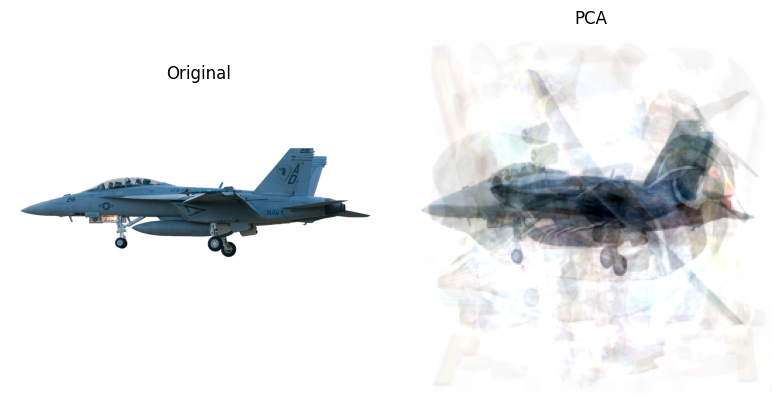

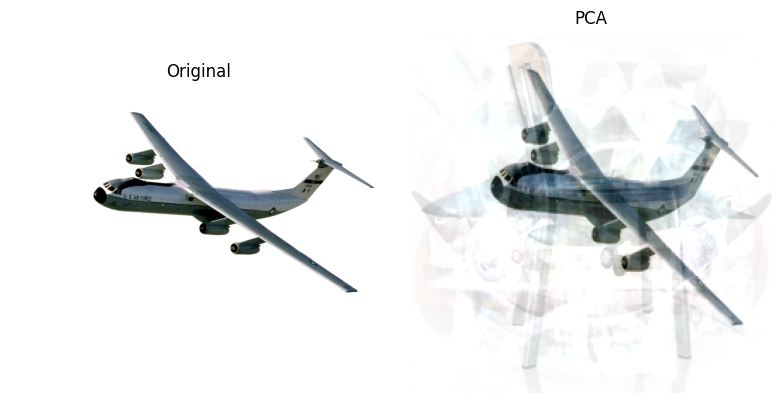

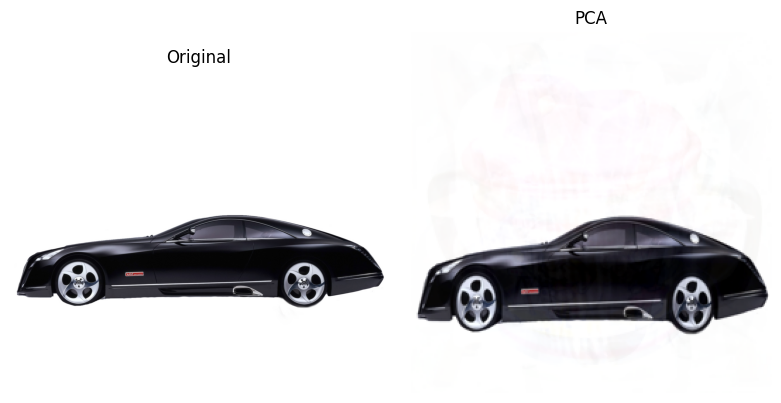

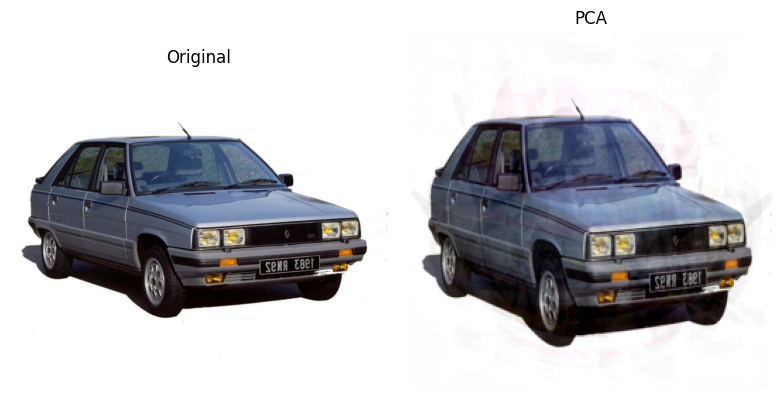

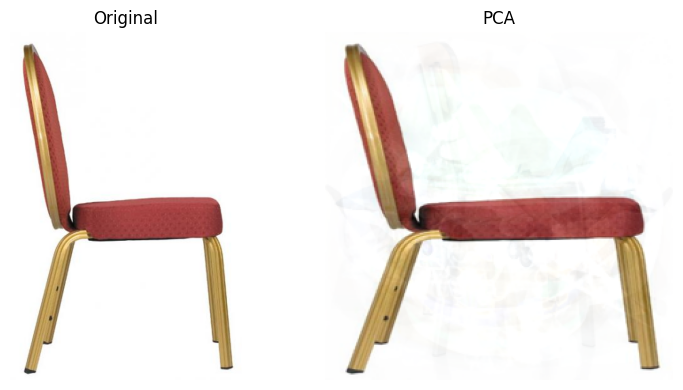

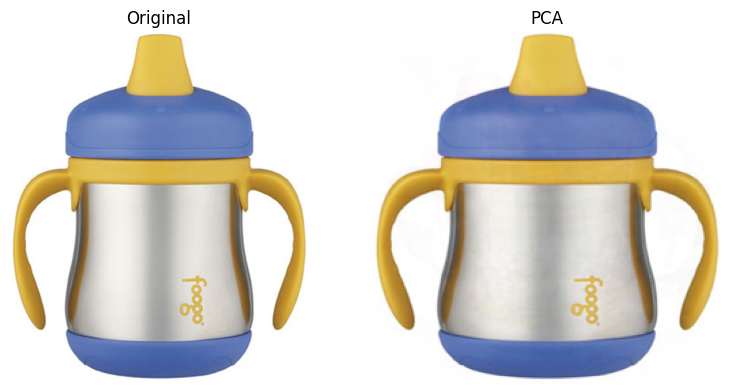

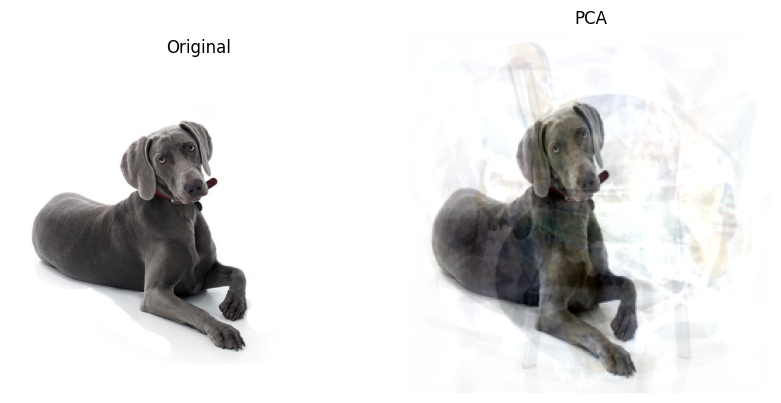

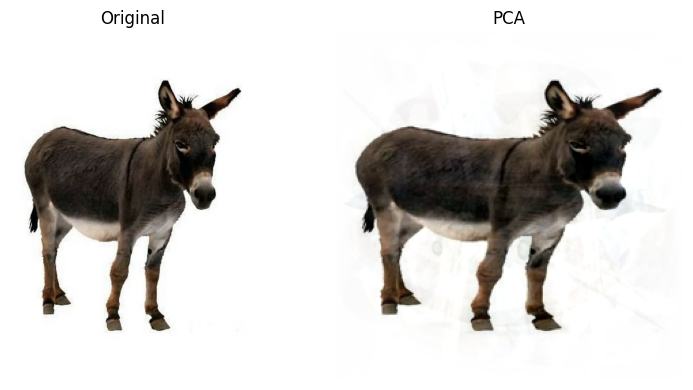

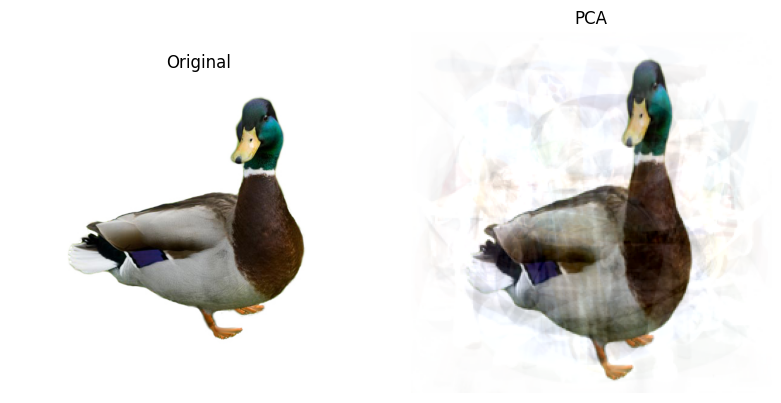

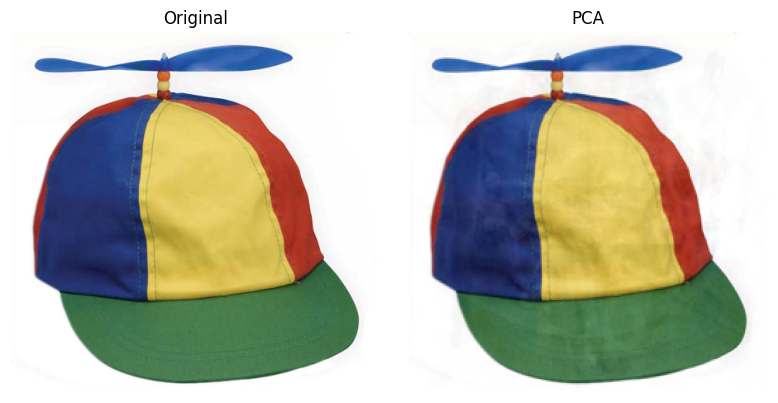

In [ ]:
side_by_side(img_pairs)

In [ ]:
# grayscale_pca_images = apply_pca("realistic", image_names, dir_PCAs["realistic"], grayscale=True)
# grayscale_img_pairs = list(zip(og_images, grayscale_pca_images))

In [ ]:
# side_by_side(grayscale_img_pairs)

Curiously, while it does not seem to have had an appreciable impact on number of components or the general integrity of the images, the ghost details are easier to discern as a human, such as the hat for the second airplane or the car for the duck.

In [ ]:
def get_image_names(directory):
  filenames = []
  for filename in os.listdir(dir_info.at[directory, "dir_path"]):
    filenames.append(filename)
  filenames.sort()
  return np.array(filenames)

In [ ]:
for dir in dir_info.index:
  dir_info.at[dir, "image_names"] = get_image_names(dir)

In [ ]:
dir_info

,dir_path,pca_fn,images,pca_transformed_images,image_names,image_labels
dir_name,,,,,,
blurred,image_files/blurred,PCA(n_components=0.95),"[[255, 255, 255, 255, 255, 255, 255, 255, 255,...",None,"[AirplaneSide_V1.jpg, AirplaneSide_V2.jpg, Air...",None
features,image_files/features,PCA(n_components=0.95),"[[255, 255, 255, 255, 255, 255, 255, 255, 255,...",None,"[AirplaneSide_V1.jpg, AirplaneThreeQuarters_V1...",None
geons,image_files/geons,PCA(n_components=0.95),"[[255, 255, 255, 255, 255, 255, 255, 255, 255,...",None,"[AirplaneSide_v1.jpg, AirplaneThreeQuarter_4.p...",None
realistic,image_files/realistic,PCA(n_components=0.95),"[[255, 255, 255, 255, 255, 255, 255, 255, 255,...",None,"[AirplaneSide_v1.jpg, AirplaneThree-Quarter_V4...",None
silhouettes,image_files/silhouettes,PCA(n_components=0.95),"[[255, 255, 255, 255, 255, 255, 255, 255, 255,...",None,"[AirplaneSide_V1.jpg, AirplaneThreeQuarters_V1...",None


# Part 3
Each of the images belongs to one of eight clusters (Airplane, Car, Chair, Cup, Dog, Donkey, Duck, Hat). The clusters is indicated by the image name. We will now try to see if the visualization can help us identify different clusters.


## 3A
For each condition (folder) use PCA to reduce dimensionality to only 2 dimensions. How much of the variance is explained with the first two principal components for each condition? [3 points].

In [ ]:
pcas_2D = process_directories(dir_info.index, n_components=2)

Number of components for blurred: 2
Number of components for features: 2
Number of components for geons: 2
Number of components for realistic: 2
Number of components for silhouettes: 2


In [ ]:
for i, key in enumerate(dir_info.index):
  print(f"Explained variance for {key}: {sum(pcas_2D[i].explained_variance_ratio_)*100:,.2f}%")

Explained variance for blurred: 47.05%
Explained variance for features: 20.97%
Explained variance for geons: 26.92%
Explained variance for realistic: 26.95%
Explained variance for silhouettes: 30.90%


In [ ]:
# grayscale_pcas_2D = process_directories(dir_paths.keys(), n_components=2, grayscale=True)
# print()
# for i, key in enumerate(dir_paths):
#   print(f"Explained variance for {key}: {sum(grayscale_pcas_2D[i].explained_variance_ratio_)*100:,.2f}%")

## 3B
Plot a 2D scatter plot of the images spanned by the first two principal components. Each image will be represented with a dot. Make the color of the dot correspond to the image class (so you will have eight different colors). Repeat the process and create the same type of plots for t-SNE, LLE and UMAP. [6 points]

(A modified version of) Claude's option that was not a bunch of if statements.

In [ ]:
categories = {
    "airplane": 0,
    "car": 1,
    "chair": 2,
    "cup": 3,
    "dog": 4,
    "donkey": 5,
    "duck": 6,
    "hat": 7,
    "unknown": 8
}

In [ ]:
def categorize_images(directory):
  labels = []
  for image_name in dir_info.at[dir, "image_names"]:
    image_name = image_name.lower()
    for category in categories.keys():
      if image_name.startswith(category):
        labels.append(categories[category])
        break  # Stop after first match
    else:
      labels.append(categories["unknown"])

  labels = np.array(labels)
  return labels

In [ ]:
for dir in dir_info.index:
  dir_info.at[dir, "image_labels"] = categorize_images(dir)

In [ ]:
type(dir_info.at["realistic", "image_labels"])

numpy.ndarray

Scatterplot courtesy of Claude

In [ ]:
from sklearn.manifold import LocallyLinearEmbedding as LLE
from sklearn.manifold import TSNE
from umap import UMAP

In [ ]:
np.array(dir_info.at["realistic", "images"]).shape

(41, 196608)

In [ ]:
def plot_scatter(directory, model):
    """
    Plot 2D scatter of images using first 2 PCA components.

    Parameters:
    -----------
    all_images : np.array
        All flattened images (n_images, n_pixels)
    labels : np.array
        Category label for each image (0-7 for 8 classes)
    class_names : list
        Names like ['Airplane', 'Car', 'Chair', ...]
    """
    # Fit model
    model = model(n_components=2)  # Only need 2 for visualization
    images = dir_info.at[directory, "images"]
    images_set = model.fit_transform(images)

    labels = dir_info.at[directory, "image_labels"]
    class_names = list(categories.keys())

    # Create scatter plot
    plt.figure(figsize=(10, 8))

    # Use different color for each class
    colors = plt.cm.tab10(np.linspace(0, 1, 8))

    for class_idx in range(8):
        mask = labels == class_idx
        plt.scatter(images_set[mask, 0],  # First PC
                   images_set[mask, 1],   # Second PC
                   c=[colors[class_idx]],
                   label=class_names[class_idx],
                   alpha=0.7,
                   s=50)

    plt.xlabel(f'First Principal Component')
    plt.ylabel(f'Second Principal Component')
    plt.title(f'Images in {model.__class__.__name__} Space (First 2 Components)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

It's difficult to see any clustering. The best trends are for Airplane, Hat, and Car, and even then the latter forms more of an arc than a cluster.

In [ ]:
models = [PCA, LLE, TSNE, UMAP]

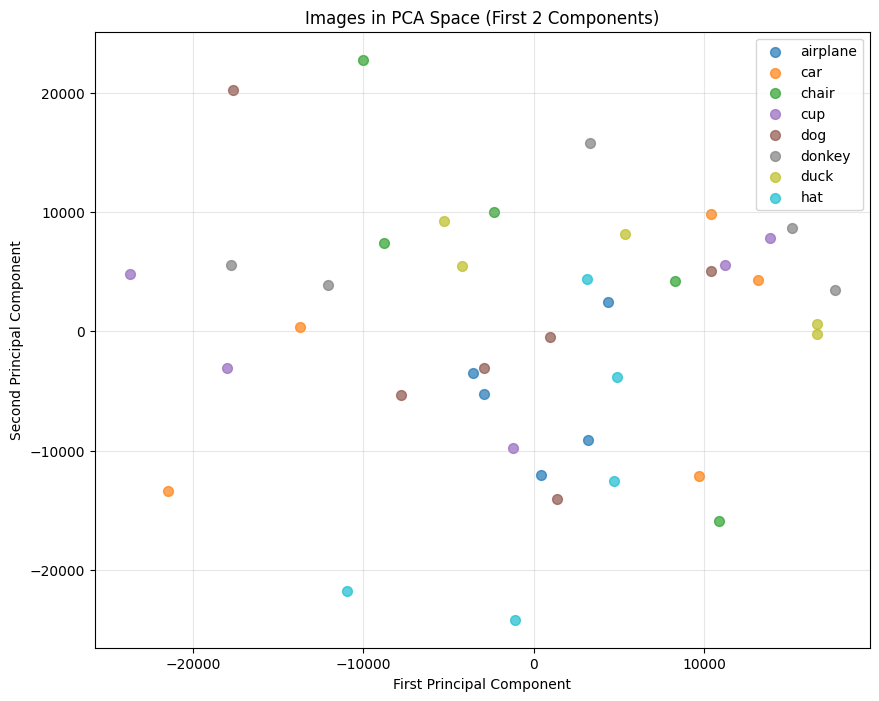

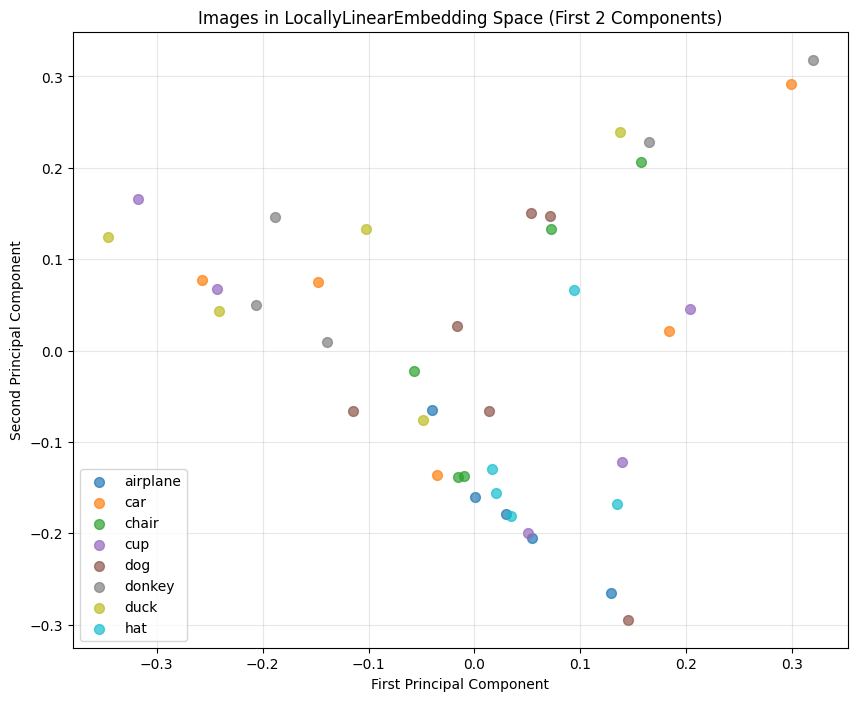

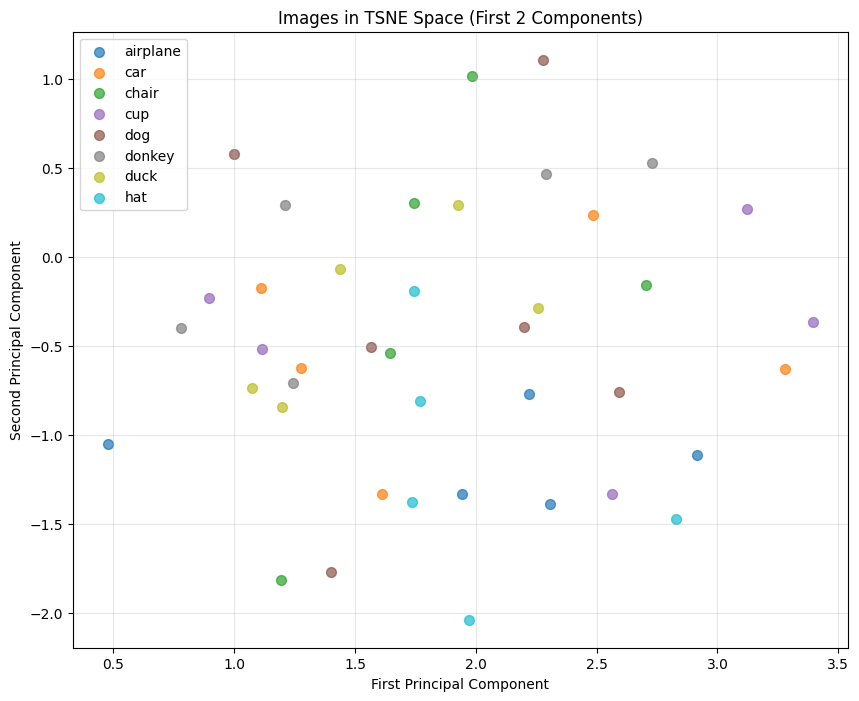

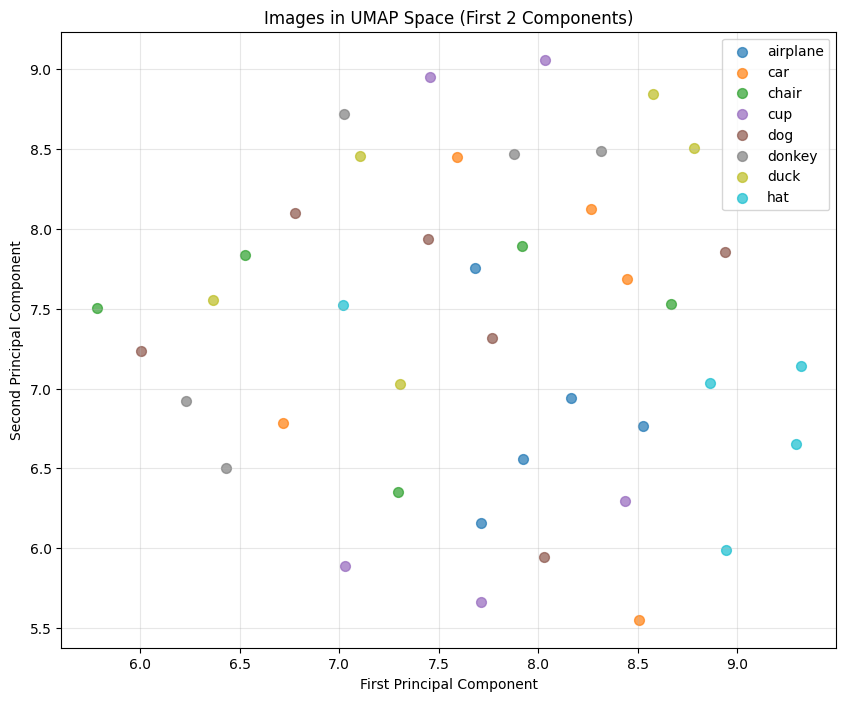

In [ ]:
for model in models:
  plot_scatter("realistic", model)

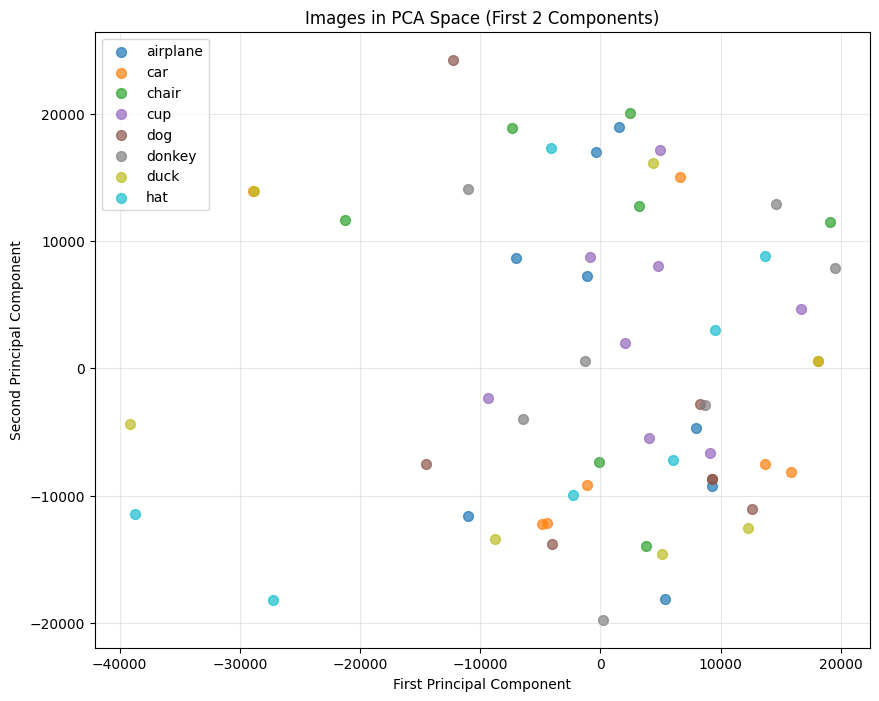

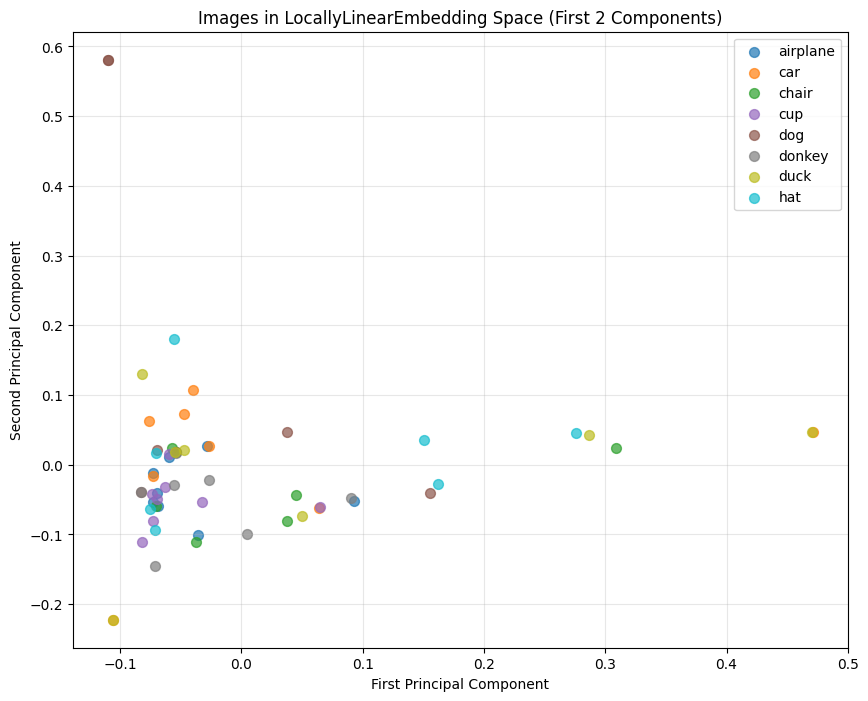

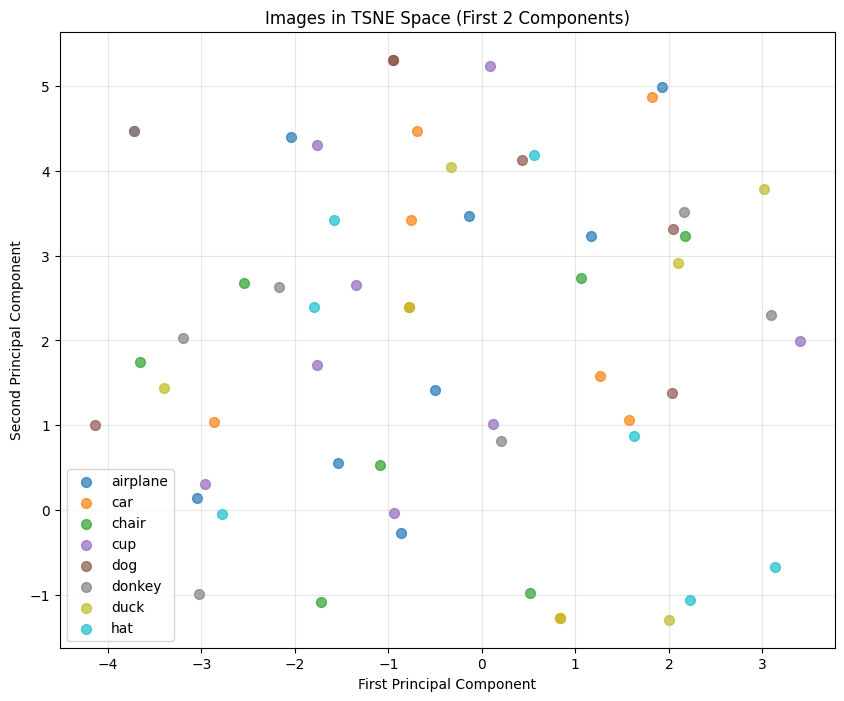

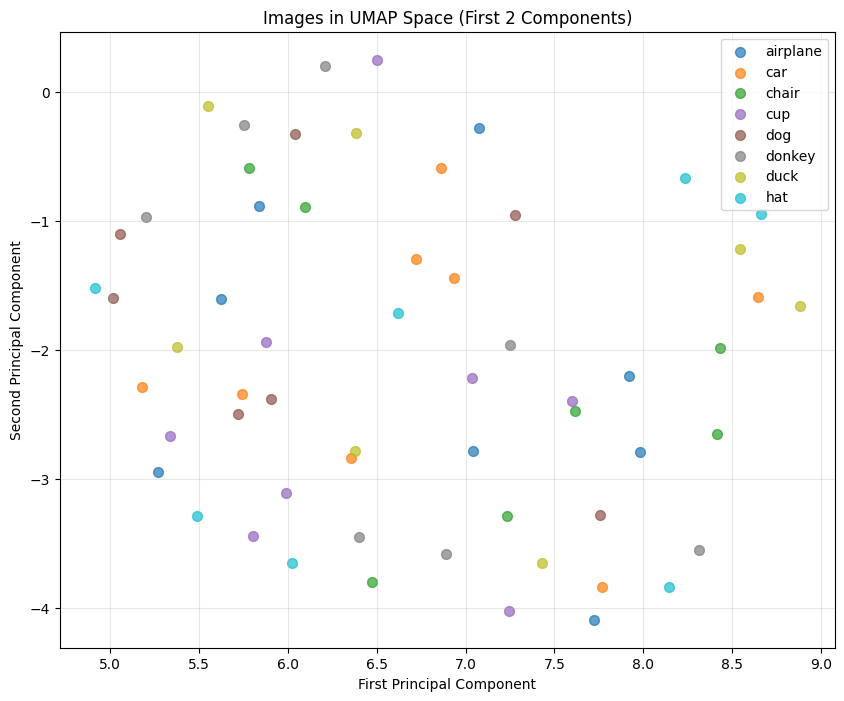

In [ ]:
for model in models:
  plot_scatter("geons", model)

# Part 4
Cluster the images in each condition using K-Means (apply K-means separately to images from each folder).

## 4A
To make the process faster, reduce the dimensionality using PCA, but keep at least 95% of the variance. Determine the number of clusters using one of the techniques we discussed in class, suitable for the K-means algorithm. [2 points]

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

def get_best_k(directory, max_k = 16):
  """
  Arguments:
    max_k: the maximum number of clusters to try, 16 defaulted since 8 known clusters
  Returns:
    the number of clusters that maximizes silhouette score
  """
  scores = []

  pca = dir_info.at[directory, "pca_fn"]
  images = load_images(directory)
  images_pca = pca.transform(images)

  for k in range(2, max_k+1):
    kmeans = KMeans(n_clusters=k, random_state=SEED)
    labels = kmeans.fit_predict(images_pca)
    score = silhouette_score(images_pca, labels)
    scores.append(score)

  return np.argmax(scores) + 2



In [ ]:
print("Based on silhouette scores, the best number of clusters for k-means are as follows:")
for directory in dir_info.index:
  print(f"{directory}: {get_best_k(directory)}")

Based on silhouette scores, the best number of clusters for k-means are as follows:
blurred: 16
features: 2
geons: 16
realistic: 2
silhouettes: 2


## 4B
Set the number of clusters to 8 (ground truth), report clustering accuracy (choose an appropriate mapping) and show a confusion matrix. [3 points]

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
from scipy.optimize import linear_sum_assignment

# Claude implementation of Hungarian Algorithm
def find_best_mapping(true_labels, cluster_labels, n_clusters=8):
    """
    Find the best mapping between cluster labels and true labels.
    Uses the Hungarian algorithm for optimal assignment.

    Parameters:
    -----------
    true_labels : np.array
        Ground truth labels
    cluster_labels : np.array
        Predicted cluster labels
    n_clusters : int
        Number of clusters

    Returns:
    --------
    mapping : dict
        Dictionary mapping cluster_id -> true_label
    """
    # Create confusion matrix (clusters vs true labels)
    cm = confusion_matrix(true_labels, cluster_labels)

    # Use Hungarian algorithm to find best mapping
    # We want to maximize matches, so negate the matrix
    row_ind, col_ind = linear_sum_assignment(-cm)

    # Create mapping dictionary
    mapping = {cluster_id: true_label for cluster_id, true_label in zip(col_ind, row_ind)}

    return mapping

def apply_mapping(cluster_labels, mapping):
    """Apply mapping to convert cluster labels to predicted true labels."""
    return np.array([mapping[label] for label in cluster_labels])

In [ ]:
print(categories)

{'airplane': 0, 'car': 1, 'chair': 2, 'cup': 3, 'dog': 4, 'donkey': 5, 'duck': 6, 'hat': 7, 'unknown': 8}


In [ ]:
for dir in dir_info.index:
  pca = dir_info.at[dir, "pca_fn"]
  images = load_images(dir)
  images_pca = pca.transform(images)

  images_pca = np.array(images_pca)
  dir_info.at[dir, "pca_transformed_images"] = images_pca

In [ ]:
dir_info.head()

,dir_path,pca_fn,images,pca_transformed_images,image_names,image_labels
dir_name,,,,,,
blurred,image_files/blurred,PCA(n_components=0.95),"[[255, 255, 255, 255, 255, 255, 255, 255, 255,...","[[-18194.50866511677, 2683.591236990502, 8106....","[AirplaneSide_V1.jpg, AirplaneSide_V2.jpg, Air...","[0, 0, 0, 0, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, ..."
features,image_files/features,PCA(n_components=0.95),"[[255, 255, 255, 255, 255, 255, 255, 255, 255,...","[[7436.131149977235, -39.19702546367989, 358.7...","[AirplaneSide_V1.jpg, AirplaneThreeQuarters_V1...","[0, 0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2, 8, 3, ..."
geons,image_files/geons,PCA(n_components=0.95),"[[255, 255, 255, 255, 255, 255, 255, 255, 255,...","[[5366.867511218814, -18076.461605499557, 4011...","[AirplaneSide_v1.jpg, AirplaneThreeQuarter_4.p...","[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, ..."
realistic,image_files/realistic,PCA(n_components=0.95),"[[255, 255, 255, 255, 255, 255, 255, 255, 255,...","[[-3565.259899442419, -3521.355519842051, 2396...","[AirplaneSide_v1.jpg, AirplaneThree-Quarter_V4...","[0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, ..."
silhouettes,image_files/silhouettes,PCA(n_components=0.95),"[[255, 255, 255, 255, 255, 255, 255, 255, 255,...","[[-31357.6251742659, -2933.162406382066, -3065...","[AirplaneSide_V1.jpg, AirplaneThreeQuarters_V1...","[0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 3, ..."


In [ ]:
def test_kmeans(directory):
  images = dir_info.at[directory, "images"]
  pca = dir_info.at[directory, "pca_fn"]
  images_pca = dir_info.at[directory, "pca_transformed_images"]
  true_labels = dir_info.at[directory, "image_labels"]

  kmeans = KMeans(n_clusters=8, random_state=SEED)
  predicted_clusters = kmeans.fit_predict(images_pca)

  mapping = find_best_mapping(true_labels, predicted_clusters, n_clusters=8)

  # NOTE: Interestingly, Claude couldn't pick up on the need for a reversed dict
  # here. I had to notice that
  rev_categories = {v: k for k, v in categories.items()}
  print(f"\nCluster to Label Mapping for {directory}:")
  for cluster_id, true_label in mapping.items():
      print(f"  Cluster {cluster_id} -> {rev_categories[true_label]}")

  predicted_labels = apply_mapping(predicted_clusters, mapping)

  #---#
  # Calculate accuracy
  accuracy = accuracy_score(true_labels, predicted_labels)
  print(f"\nClustering Accuracy: {accuracy:.2%}")

  # Create confusion matrix
  cm = confusion_matrix(true_labels, predicted_labels)

  # Plot confusion matrix
  plt.figure(figsize=(10, 8))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
              xticklabels=categories,
              yticklabels=categories,
              cbar_kws={'label': 'Count'})
  plt.xlabel('Predicted Label', fontsize=12)
  plt.ylabel('True Label', fontsize=12)
  plt.title(f'Confusion Matrix - {directory}\nAccuracy: {accuracy:.2%}',
            fontsize=14, fontweight='bold')
  plt.tight_layout()
  plt.show()

  # return accuracy, cm, mapping, predicted_labels



Cluster to Label Mapping for realistic:
  Cluster 4 -> airplane
  Cluster 0 -> car
  Cluster 6 -> chair
  Cluster 5 -> cup
  Cluster 1 -> dog
  Cluster 3 -> donkey
  Cluster 7 -> duck
  Cluster 2 -> hat

Clustering Accuracy: 31.71%


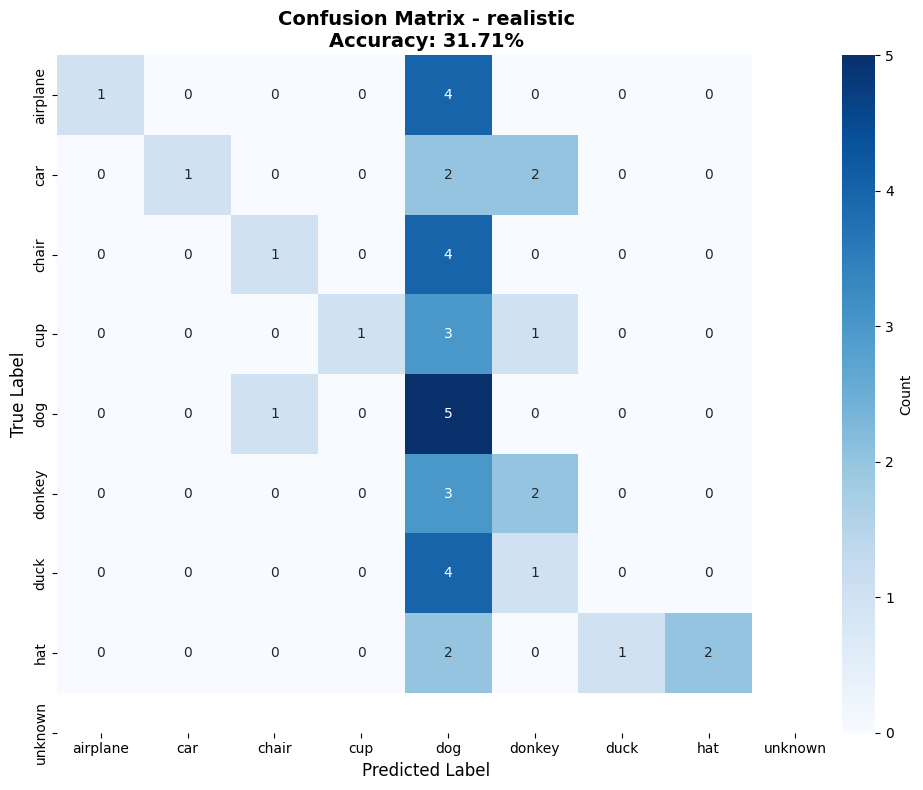

In [ ]:
test_kmeans("realistic")

## 4C
Repeat step B, but instead of features derived using PCA, use features obtained with a pretrained ResNet model - use penultimate layer (size of the ResNet model and data used for pretraining are up to you; note that you will need to resize images to 224×224 for ResNet). [3 points]

After going back and tidying up all my code to use Dataframes and process what it's been doing, I've chosen to lean on Claude to help with the rest to take advantage of my Thanksgiving break.

NOTE: Trying to process the images as they were was crashing due to RAM limits. Hence this downsizing.

In [ ]:
dir_info["images_downsized"] = None

In [ ]:
from PIL import Image

# Once again, assisted by Claude, but curiously it did not do things in the best way
# in terms of using the existing Dataframe
def downsize_images(directory, target_size=(224, 224)):
    """
    Downsize a list/array of images.

    Parameters:
    -----------
    directory : str
    target_size : tuple
        Target size (width, height)

    Returns:
    --------
    downsized : np.array
        Resized images
    """
    downsized = []

    images = dir_info.at[directory, "images"]

    for img in images:
        # Convert numpy array to PIL Image
        if isinstance(img, np.ndarray):
            pil_img = Image.fromarray(img.astype('uint8'))
        else:
            pil_img = img

        if pil_img.mode != 'RGB':
          pil_img = pil_img.convert('RGB')

        # Resize
        pil_img = pil_img.resize(target_size)

        # Convert back to numpy
        downsized.append(np.array(pil_img))

    return np.array(downsized)

# Apply to all directories
for dir_name in dir_info.index:
    print(f"Downsizing images for {dir_name}...")

    original = dir_info.at[dir_name, "images"]
    downsized = downsize_images(dir_name, target_size=(224, 224))
    dir_info.at[dir_name, "images_downsized"] = downsized

    print(f"  Original shape: {original.shape}")
    print(f"  New shape: {downsized.shape}")

Downsizing images for blurred...
  Original shape: (42, 196608)
  New shape: (42, 224, 224, 3)
Downsizing images for features...
  Original shape: (42, 196608)
  New shape: (42, 224, 224, 3)
Downsizing images for geons...
  Original shape: (60, 196608)
  New shape: (60, 224, 224, 3)
Downsizing images for realistic...
  Original shape: (41, 196608)
  New shape: (41, 224, 224, 3)
Downsizing images for silhouettes...
  Original shape: (40, 196608)
  New shape: (40, 224, 224, 3)


array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
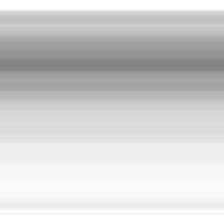

In [ ]:
dir_info.at["realistic","images_downsized"][10]

In [ ]:
import keras
import tensorflow as tf

resnet50 = keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
images = dir_info.at["realistic", "images_downsized"]
images = tf.keras.applications.resnet50.preprocess_input(images)
features = resnet50.predict(images)

2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 5s/step


Claude's implementation

In [ ]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image

# Load pretrained ResNet (you can choose resnet18, resnet34, resnet50, etc.)
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Remove the final classification layer to get penultimate layer features
resnet = torch.nn.Sequential(*list(resnet.children())[:-1])
resnet.eval()  # Set to evaluation mode

# Define image preprocessing for ResNet (requires 224x224)
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])

def extract_resnet_features_batched(images, batch_size=32):
    """
    Extract features in batches to avoid memory issues.

    Parameters:
    -----------
    images : list or array
        List of images
    batch_size : int
        Number of images to process at once

    Returns:
    --------
    features : np.array
        Feature vectors
    """
    features = []

    with torch.no_grad():
        for i in range(0, len(images), batch_size):
            batch = images[i:i + batch_size]
            batch_features = []

            for img in batch:
                # Convert numpy array to PIL Image if needed
                if isinstance(img, np.ndarray):
                    img = Image.fromarray(img.astype('uint8'))

                # Preprocess
                img_tensor = preprocess(img).unsqueeze(0)

                # Extract features
                feature = resnet(img_tensor)
                feature = feature.squeeze().cpu().numpy()  # Move to CPU immediately
                batch_features.append(feature)

            features.extend(batch_features)

            # Clear memory after each batch
            if i % 100 == 0:
                print(f"  Processed {i}/{len(images)} images...")

    return np.array(features)

In [ ]:
# Add new column for ResNet features
dir_info["resnet_features"] = None

# Extract ResNet features for each directory
for dir_name in dir_info.index:
    print(f"Extracting ResNet features for {dir_name}...")
    images = dir_info.at[dir_name, "images_downsized"]
    resnet_feats = extract_resnet_features_batched(images)
    dir_info.at[dir_name, "resnet_features"] = resnet_feats
    print(f"  Shape: {resnet_feats.shape}")

Extracting ResNet features for blurred...
  Processed 0/42 images...
  Shape: (42, 512)
Extracting ResNet features for features...
  Processed 0/42 images...
  Shape: (42, 512)
Extracting ResNet features for geons...
  Processed 0/60 images...
  Shape: (60, 512)
Extracting ResNet features for realistic...
  Processed 0/41 images...
  Shape: (41, 512)
Extracting ResNet features for silhouettes...
  Processed 0/40 images...
  Shape: (40, 512)


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, accuracy_score
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
import seaborn as sns

def cluster_accuracy(true_labels, cluster_labels):
    """
    Calculate clustering accuracy using Hungarian algorithm for optimal mapping.

    Parameters:
    -----------
    true_labels : array
        Ground truth labels
    cluster_labels : array
        Predicted cluster assignments

    Returns:
    --------
    accuracy : float
        Clustering accuracy after optimal mapping
    mapping : dict
        Optimal cluster to class mapping
    """
    # Create confusion matrix
    cm = confusion_matrix(true_labels, cluster_labels)

    # Use Hungarian algorithm to find optimal mapping
    row_ind, col_ind = linear_sum_assignment(-cm)

    # Create mapping dictionary
    mapping = {cluster: true_class for cluster, true_class in zip(col_ind, row_ind)}

    # Map cluster labels to true labels
    mapped_labels = np.array([mapping[label] for label in cluster_labels])

    # Calculate accuracy
    accuracy = accuracy_score(true_labels, mapped_labels)

    return accuracy, mapping, mapped_labels

def perform_clustering_resnet(directory, n_clusters=8):
    """
    Perform K-means clustering using ResNet features.

    Parameters:
    -----------
    directory : str
        Directory name in dir_info DataFrame
    n_clusters : int
        Number of clusters (default 8 for ground truth)
    """
    # Get ResNet features and true labels
    features = dir_info.at[directory, "resnet_features"]
    true_labels = dir_info.at[directory, "image_labels"]

    print(f"\n{'='*60}")
    print(f"Clustering for: {directory}")
    print(f"{'='*60}")
    print(f"Feature shape: {features.shape}")
    print(f"Number of samples: {len(true_labels)}")

    # Perform K-means clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(features)

    # Calculate accuracy with optimal mapping
    accuracy, mapping, mapped_labels = cluster_accuracy(true_labels, cluster_labels)

    print(f"\nClustering Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"\nOptimal Cluster to Class Mapping:")
    class_names = list(categories.keys())
    for cluster, true_class in mapping.items():
        print(f"  Cluster {cluster} -> Class {true_class} ({class_names[true_class]})")

    # Create confusion matrix with mapped labels
    cm = confusion_matrix(true_labels, mapped_labels)

    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.xlabel('Predicted Class (after mapping)')
    plt.ylabel('True Class')
    plt.title(f'Confusion Matrix - {directory.capitalize()} (ResNet Features)\nAccuracy: {accuracy:.4f}')
    plt.tight_layout()
    plt.show()

    return accuracy, mapping, cluster_labels


Clustering for: blurred
Feature shape: (42, 512)
Number of samples: 42

Clustering Accuracy: 0.3333 (33.33%)

Optimal Cluster to Class Mapping:
  Cluster 6 -> Class 0 (airplane)
  Cluster 0 -> Class 1 (car)
  Cluster 2 -> Class 2 (chair)
  Cluster 3 -> Class 3 (cup)
  Cluster 4 -> Class 4 (dog)
  Cluster 5 -> Class 5 (donkey)
  Cluster 1 -> Class 6 (duck)
  Cluster 7 -> Class 7 (hat)


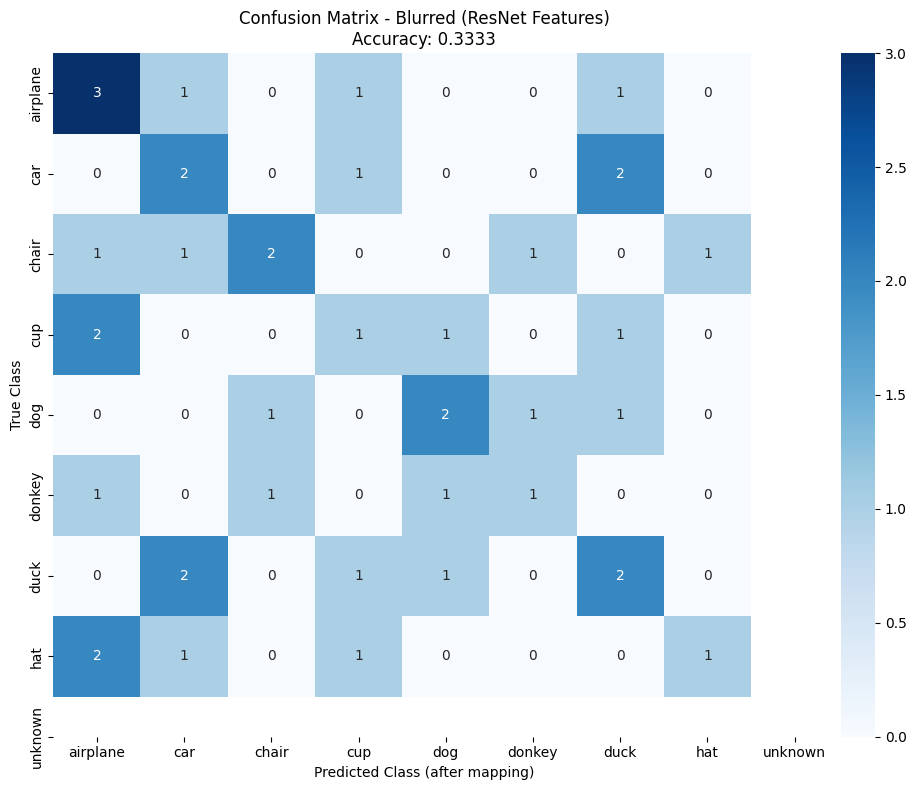


Clustering for: features
Feature shape: (42, 512)
Number of samples: 42

Clustering Accuracy: 0.3095 (30.95%)

Optimal Cluster to Class Mapping:
  Cluster 3 -> Class 0 (airplane)
  Cluster 6 -> Class 1 (car)
  Cluster 1 -> Class 2 (chair)
  Cluster 2 -> Class 3 (cup)
  Cluster 0 -> Class 4 (dog)
  Cluster 5 -> Class 5 (donkey)
  Cluster 7 -> Class 6 (duck)
  Cluster 4 -> Class 7 (hat)
  Cluster 8 -> Class 8 (unknown)


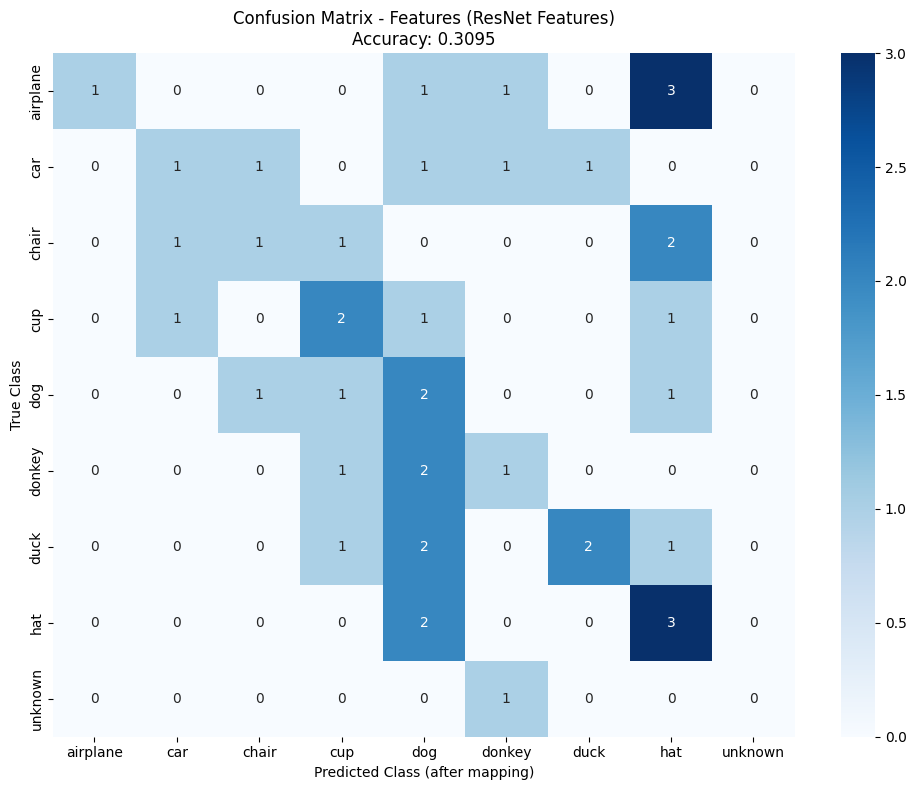


Clustering for: geons
Feature shape: (60, 512)
Number of samples: 60

Clustering Accuracy: 0.3000 (30.00%)

Optimal Cluster to Class Mapping:
  Cluster 6 -> Class 0 (airplane)
  Cluster 3 -> Class 1 (car)
  Cluster 2 -> Class 2 (chair)
  Cluster 4 -> Class 3 (cup)
  Cluster 7 -> Class 4 (dog)
  Cluster 5 -> Class 5 (donkey)
  Cluster 1 -> Class 6 (duck)
  Cluster 0 -> Class 7 (hat)
  Cluster 8 -> Class 8 (unknown)


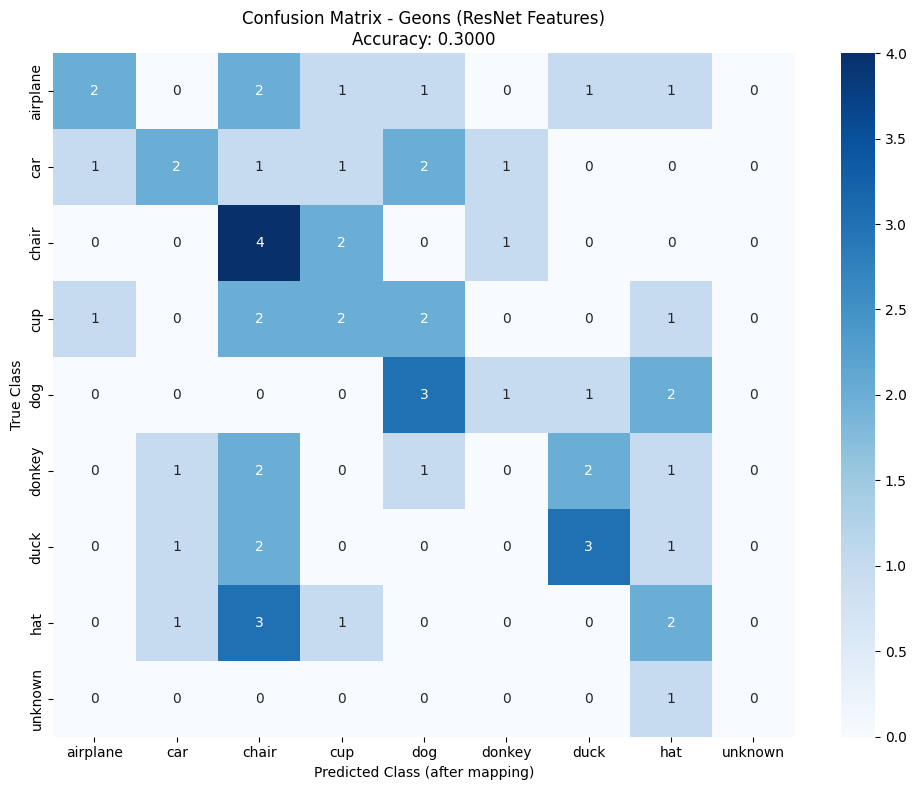


Clustering for: realistic
Feature shape: (41, 512)
Number of samples: 41

Clustering Accuracy: 0.3415 (34.15%)

Optimal Cluster to Class Mapping:
  Cluster 5 -> Class 0 (airplane)
  Cluster 1 -> Class 1 (car)
  Cluster 4 -> Class 2 (chair)
  Cluster 0 -> Class 3 (cup)
  Cluster 7 -> Class 4 (dog)
  Cluster 6 -> Class 5 (donkey)
  Cluster 2 -> Class 6 (duck)
  Cluster 3 -> Class 7 (hat)


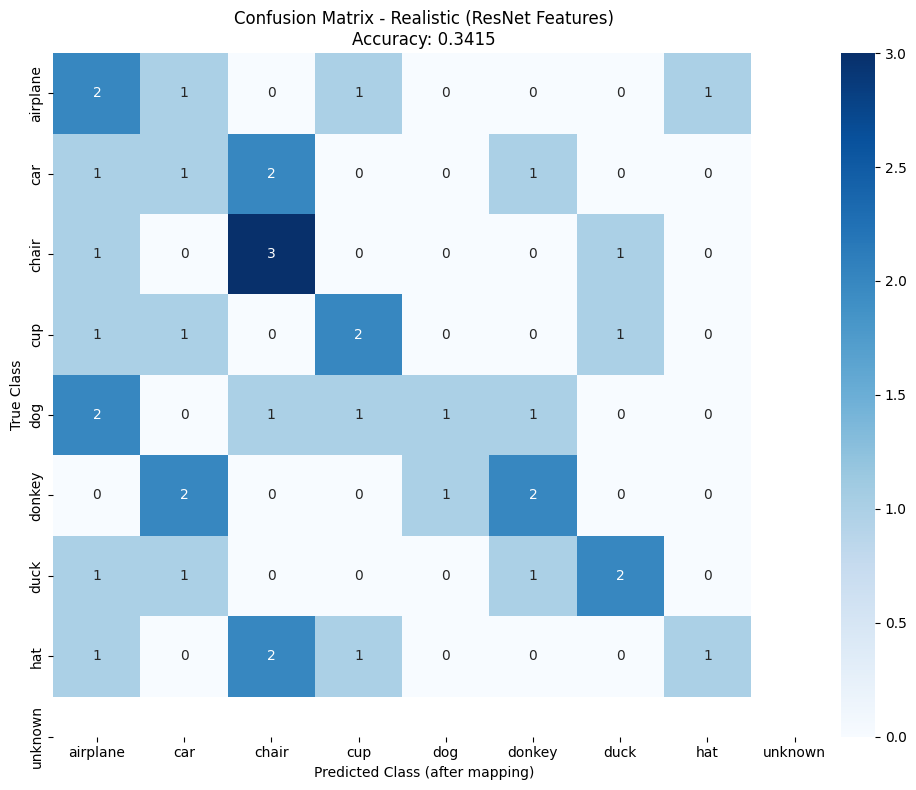


Clustering for: silhouettes
Feature shape: (40, 512)
Number of samples: 40

Clustering Accuracy: 0.3250 (32.50%)

Optimal Cluster to Class Mapping:
  Cluster 2 -> Class 0 (airplane)
  Cluster 6 -> Class 1 (car)
  Cluster 0 -> Class 2 (chair)
  Cluster 5 -> Class 3 (cup)
  Cluster 7 -> Class 4 (dog)
  Cluster 3 -> Class 5 (donkey)
  Cluster 1 -> Class 6 (duck)
  Cluster 4 -> Class 7 (hat)


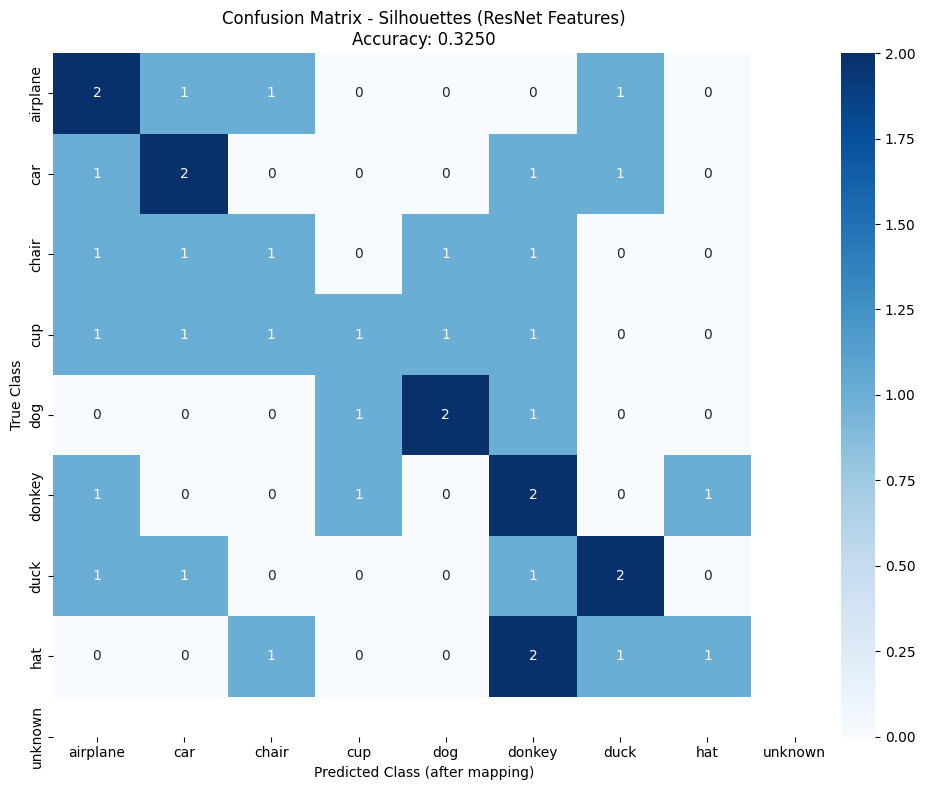


SUMMARY OF CLUSTERING ACCURACIES (ResNet Features)
blurred        : 0.3333 (33.33%)
features       : 0.3095 (30.95%)
geons          : 0.3000 (30.00%)
realistic      : 0.3415 (34.15%)
silhouettes    : 0.3250 (32.50%)


In [ ]:
# Perform clustering for each directory
results = {}

for dir_name in dir_info.index:
    accuracy, mapping, clusters = perform_clustering_resnet(dir_name, n_clusters=8)
    results[dir_name] = {
        'accuracy': accuracy,
        'mapping': mapping,
        'clusters': clusters
    }

# Summary of results
print("\n" + "="*60)
print("SUMMARY OF CLUSTERING ACCURACIES (ResNet Features)")
print("="*60)
for dir_name, result in results.items():
    print(f"{dir_name:15s}: {result['accuracy']:.4f} ({result['accuracy']*100:.2f}%)")

# Part 5
Cluster the in each condition using EM.

## 5A
Reduce again the dimensionality using PCA, but keep at least 95% of the variance. Determine the number of clusters using one of the techniques we discussed in class, suitable for the EM algorithm. [2 points]

In [ ]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

def find_optimal_clusters_bic(features, max_clusters=16, dir_name=""):
    """
    Find optimal number of clusters using BIC criterion for EM.
    Lower BIC is better.
    """
    bic_scores = []
    aic_scores = []
    k_range = range(2, max_clusters + 1)

    print(f"\nTesting k from 2 to {max_clusters}...")
    for k in k_range:
        gmm = GaussianMixture(n_components=k, random_state=42, n_init=10)
        gmm.fit(features)
        bic = gmm.bic(features)
        aic = gmm.aic(features)
        bic_scores.append(bic)
        aic_scores.append(aic)
        print(f"  k={k}: BIC={bic:.2f}, AIC={aic:.2f}")

    # Optimal k is where BIC is minimum
    optimal_k_bic = k_range[np.argmin(bic_scores)]
    optimal_k_aic = k_range[np.argmin(aic_scores)]

    # Plot
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(k_range, bic_scores, 'bo-', linewidth=2, markersize=8)
    plt.axvline(x=optimal_k_bic, color='r', linestyle='--', linewidth=2,
                label=f'Optimal k={optimal_k_bic}')
    plt.xlabel('Number of Clusters', fontsize=12)
    plt.ylabel('BIC Score', fontsize=12)
    plt.title(f'BIC vs Number of Clusters\n{dir_name}', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(k_range, aic_scores, 'go-', linewidth=2, markersize=8)
    plt.axvline(x=optimal_k_aic, color='r', linestyle='--', linewidth=2,
                label=f'Optimal k={optimal_k_aic}')
    plt.xlabel('Number of Clusters', fontsize=12)
    plt.ylabel('AIC Score', fontsize=12)
    plt.title(f'AIC vs Number of Clusters\n{dir_name}', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\nOptimal k (BIC): {optimal_k_bic}")
    print(f"Optimal k (AIC): {optimal_k_aic}")

    return optimal_k_bic, bic_scores, aic_scores

In [ ]:
dir_info.columns

Index(['dir_path', 'pca_fn', 'images', 'pca_transformed_images', 'image_names',
       'image_labels', 'images_downsized', 'resnet_features'],
      dtype='object')


Determining optimal clusters for: blurred

Testing k from 2 to 15...
  k=2: BIC=12876.16, AIC=12217.58
  k=3: BIC=9965.12, AIC=8976.39
  k=4: BIC=6499.14, AIC=5180.25
  k=5: BIC=4861.35, AIC=3212.30
  k=6: BIC=3426.26, AIC=1447.05
  k=7: BIC=3256.39, AIC=947.02
  k=8: BIC=3478.52, AIC=839.00
  k=9: BIC=3163.78, AIC=194.11
  k=10: BIC=3699.12, AIC=399.28
  k=11: BIC=3636.33, AIC=6.34
  k=12: BIC=4013.76, AIC=53.61
  k=13: BIC=4299.69, AIC=9.39
  k=14: BIC=4762.56, AIC=142.10
  k=15: BIC=5267.10, AIC=316.48


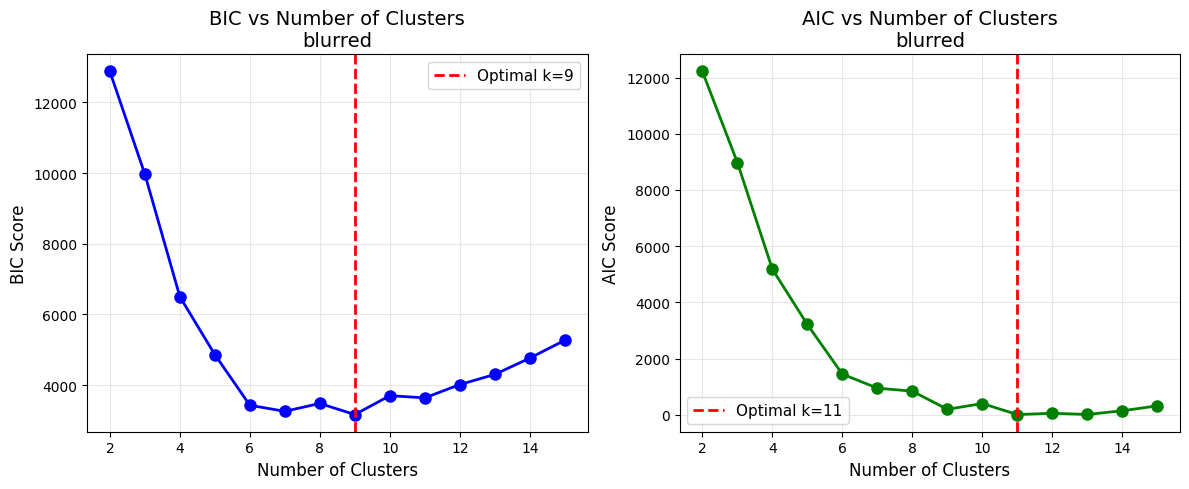


Optimal k (BIC): 9
Optimal k (AIC): 11

Determining optimal clusters for: features

Testing k from 2 to 15...
  k=2: BIC=14139.17, AIC=12191.24
  k=3: BIC=8894.91, AIC=5972.15
  k=4: BIC=10771.58, AIC=6873.99
  k=5: BIC=12748.81, AIC=7876.39
  k=6: BIC=16192.25, AIC=10344.99
  k=7: BIC=15023.00, AIC=8200.91
  k=8: BIC=12721.79, AIC=4924.87
  k=9: BIC=12496.40, AIC=3724.64
  k=10: BIC=17734.19, AIC=7987.60
  k=11: BIC=17273.74, AIC=6552.32
  k=12: BIC=23727.20, AIC=12030.95
  k=13: BIC=18786.40, AIC=6115.31
  k=14: BIC=22755.76, AIC=9109.84
  k=15: BIC=21798.43, AIC=7177.67


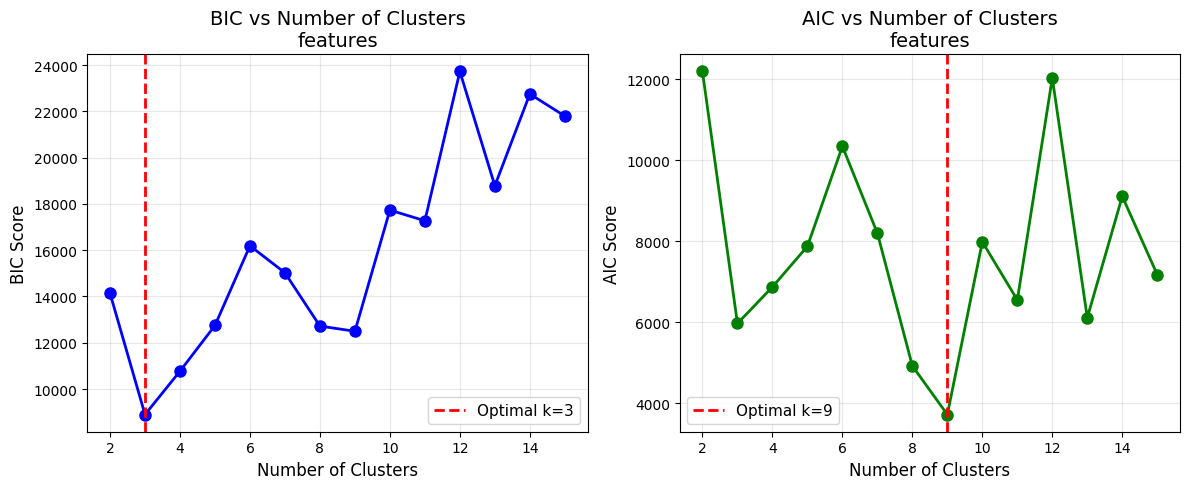


Optimal k (BIC): 3
Optimal k (AIC): 9

Determining optimal clusters for: geons

Testing k from 2 to 15...
  k=2: BIC=31197.80, AIC=27417.51
  k=3: BIC=17534.64, AIC=11863.15
  k=4: BIC=16893.31, AIC=9330.64
  k=5: BIC=11571.84, AIC=2117.96
  k=6: BIC=14250.19, AIC=2905.12
  k=7: BIC=14131.60, AIC=895.34
  k=8: BIC=15280.93, AIC=153.48
  k=9: BIC=16016.95, AIC=-1001.70
  k=10: BIC=19071.67, AIC=161.84
  k=11: BIC=22440.31, AIC=1639.28
  k=12: BIC=24567.01, AIC=1874.78
  k=13: BIC=27787.09, AIC=3203.67
  k=14: BIC=31075.97, AIC=4601.36
  k=15: BIC=33972.75, AIC=5606.94


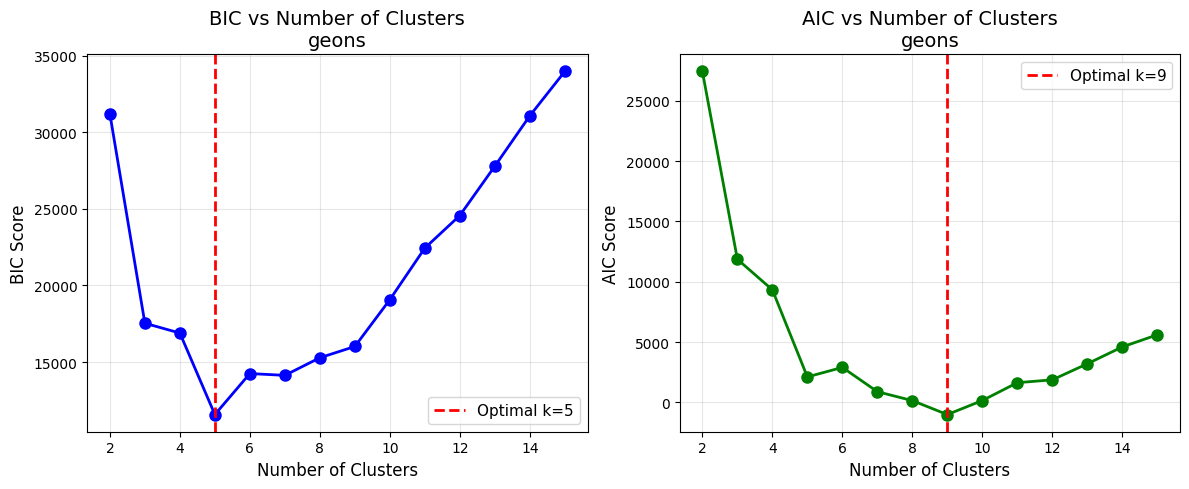


Optimal k (BIC): 5
Optimal k (AIC): 9

Determining optimal clusters for: realistic

Testing k from 2 to 15...
  k=2: BIC=14021.40, AIC=12100.48
  k=3: BIC=10408.34, AIC=7526.11
  k=4: BIC=8071.07, AIC=4227.52
  k=5: BIC=8200.70, AIC=3395.84
  k=6: BIC=7304.88, AIC=1538.71
  k=7: BIC=7341.84, AIC=614.36
  k=8: BIC=8586.14, AIC=897.34
  k=9: BIC=11225.58, AIC=2575.47
  k=10: BIC=12772.66, AIC=3161.23
  k=11: BIC=15902.43, AIC=5329.69
  k=12: BIC=16040.92, AIC=4506.86
  k=13: BIC=17901.46, AIC=5406.10
  k=14: BIC=19546.56, AIC=6089.88
  k=15: BIC=20784.87, AIC=6366.88


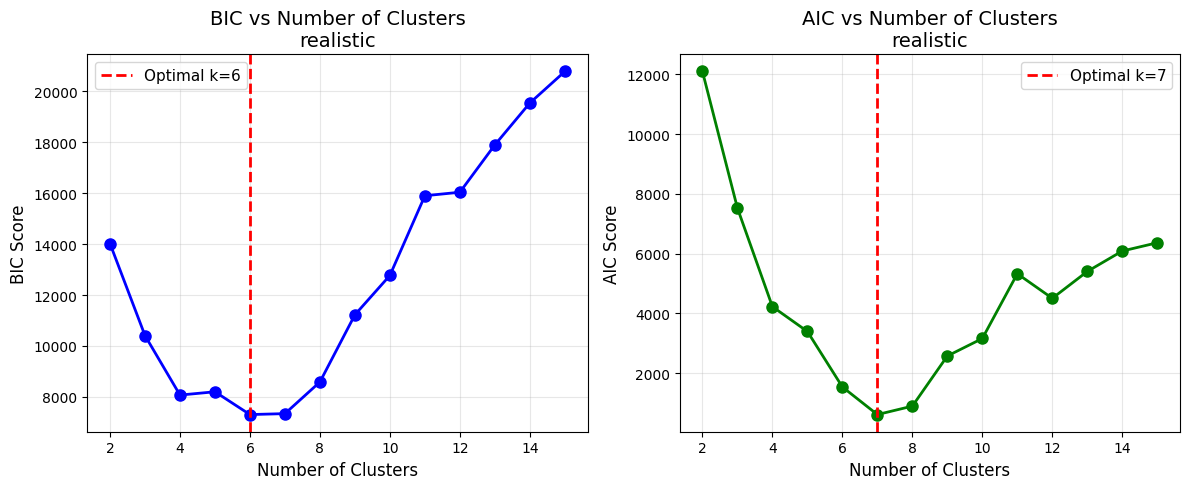


Optimal k (BIC): 6
Optimal k (AIC): 7

Determining optimal clusters for: silhouettes

Testing k from 2 to 15...
  k=2: BIC=13655.37, AIC=11873.60
  k=3: BIC=7526.89, AIC=4853.39
  k=4: BIC=6401.86, AIC=2836.64
  k=5: BIC=4889.13, AIC=432.18
  k=6: BIC=5765.70, AIC=417.02
  k=7: BIC=6131.96, AIC=-108.45
  k=8: BIC=7682.10, AIC=549.96
  k=9: BIC=8599.01, AIC=575.14
  k=10: BIC=10597.44, AIC=1681.84
  k=11: BIC=11712.44, AIC=1905.12
  k=12: BIC=12943.19, AIC=2244.14
  k=13: BIC=14367.96, AIC=2777.18
  k=14: BIC=16827.06, AIC=4344.55
  k=15: BIC=17801.75, AIC=4427.51


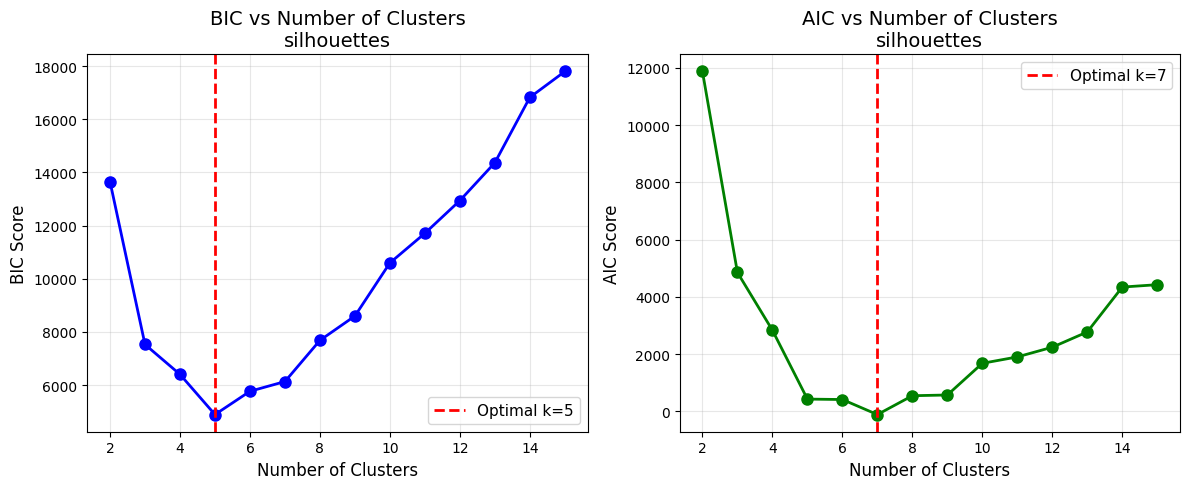


Optimal k (BIC): 5
Optimal k (AIC): 7

SUMMARY: Optimal Number of Clusters (BIC)
blurred        : k = 9
features       : k = 3
geons          : k = 5
realistic      : k = 6
silhouettes    : k = 5


In [ ]:
# Store optimal k for each directory
optimal_clusters = {}

for dir_name in dir_info.index:
    print(f"\n{'='*60}")
    print(f"Determining optimal clusters for: {dir_name}")
    print(f"{'='*60}")

    # Get PCA features
    features = dir_info.at[dir_name, "pca_transformed_images"]

    # Use BIC to find optimal k
    optimal_k, bic_scores, aic_scores = find_optimal_clusters_bic(
        features, max_clusters=15, dir_name=dir_name
    )

    optimal_clusters[dir_name] = optimal_k

# Summary
print("\n" + "="*60)
print("SUMMARY: Optimal Number of Clusters (BIC)")
print("="*60)
for dir_name, k in optimal_clusters.items():
    print(f"{dir_name:15s}: k = {k}")

## 5B
Set the number of clusters to 8 (ground truth), report clustering accuracy (choose an appropriate mapping) and show a confusion matrix. [3 points]


EM Clustering for: blurred
Feature shape: (42, 18)
Number of samples: 42
Number of clusters: 8 (ground truth)

Clustering Accuracy: 0.3571 (35.71%)

Optimal Cluster to Class Mapping:
  Cluster 6 -> Class 0 (airplane)
  Cluster 4 -> Class 1 (car)
  Cluster 1 -> Class 2 (chair)
  Cluster 2 -> Class 3 (cup)
  Cluster 0 -> Class 4 (dog)
  Cluster 5 -> Class 5 (donkey)
  Cluster 7 -> Class 6 (duck)
  Cluster 3 -> Class 7 (hat)


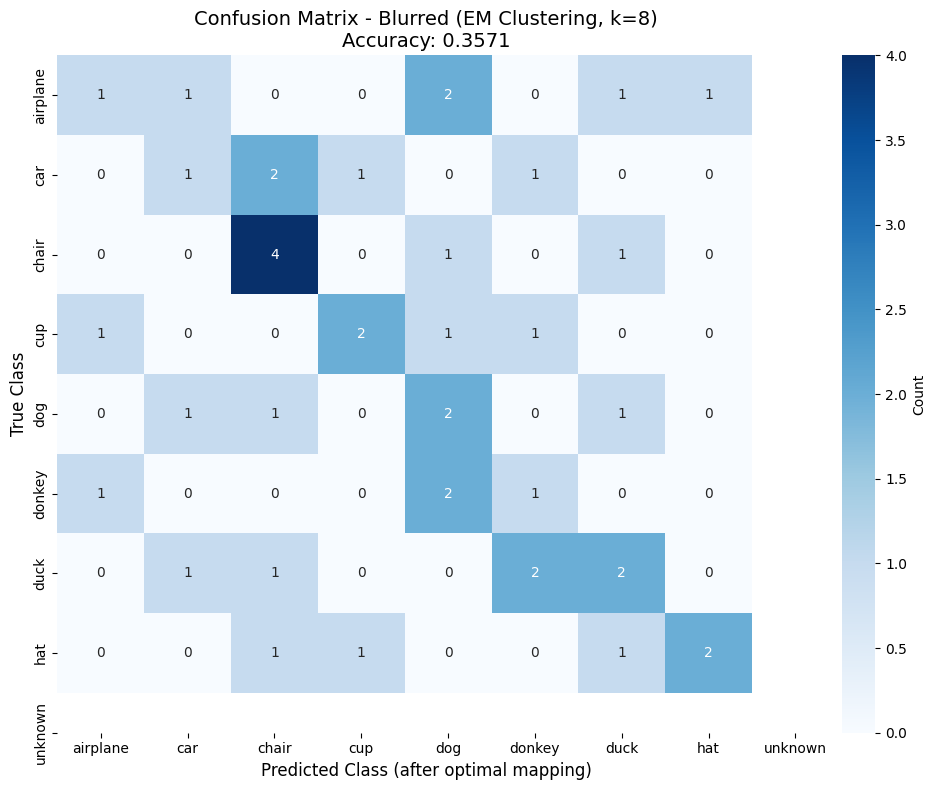


EM Clustering for: features
Feature shape: (42, 32)
Number of samples: 42
Number of clusters: 8 (ground truth)

Clustering Accuracy: 0.3571 (35.71%)

Optimal Cluster to Class Mapping:
  Cluster 6 -> Class 0 (airplane)
  Cluster 2 -> Class 1 (car)
  Cluster 3 -> Class 2 (chair)
  Cluster 5 -> Class 3 (cup)
  Cluster 1 -> Class 4 (dog)
  Cluster 7 -> Class 5 (donkey)
  Cluster 4 -> Class 6 (duck)
  Cluster 0 -> Class 7 (hat)
  Cluster 8 -> Class 8 (unknown)


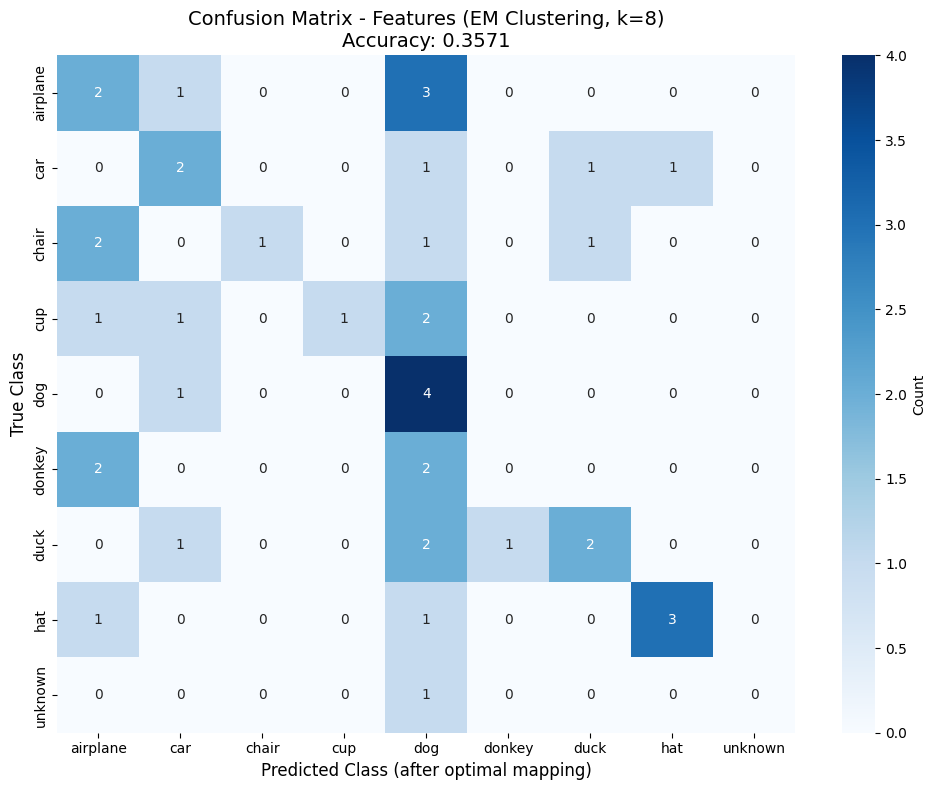


EM Clustering for: geons
Feature shape: (60, 41)
Number of samples: 60
Number of clusters: 8 (ground truth)

Clustering Accuracy: 0.2333 (23.33%)

Optimal Cluster to Class Mapping:
  Cluster 6 -> Class 0 (airplane)
  Cluster 1 -> Class 1 (car)
  Cluster 2 -> Class 2 (chair)
  Cluster 4 -> Class 3 (cup)
  Cluster 7 -> Class 4 (dog)
  Cluster 3 -> Class 5 (donkey)
  Cluster 0 -> Class 6 (duck)
  Cluster 5 -> Class 7 (hat)
  Cluster 8 -> Class 8 (unknown)


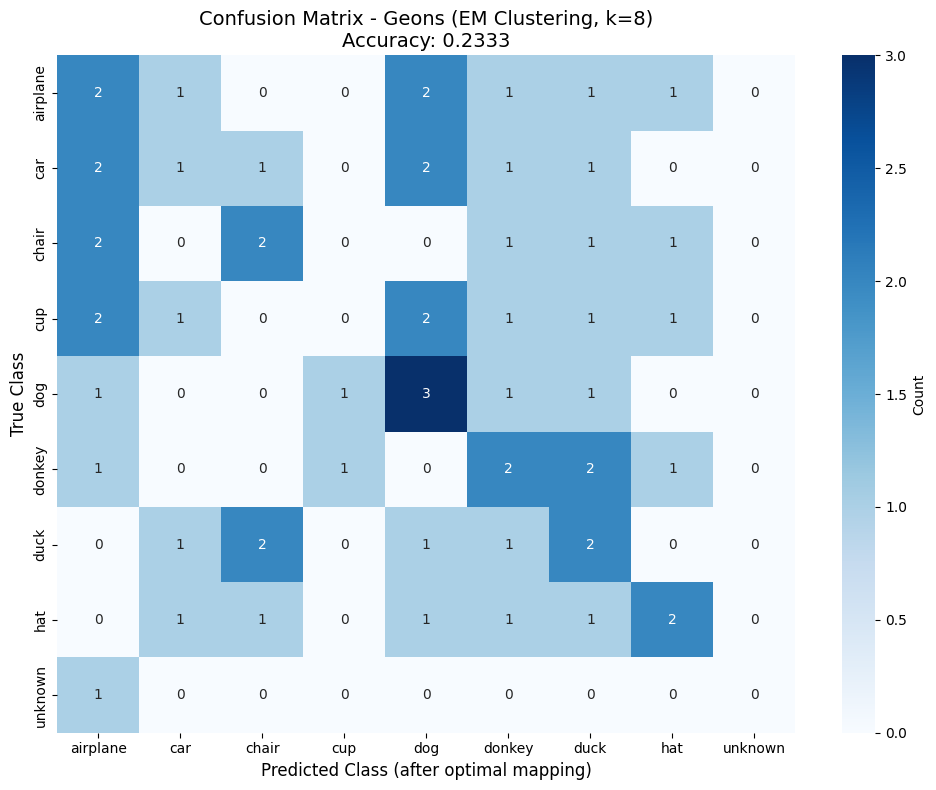


EM Clustering for: realistic
Feature shape: (41, 32)
Number of samples: 41
Number of clusters: 8 (ground truth)

Clustering Accuracy: 0.3659 (36.59%)

Optimal Cluster to Class Mapping:
  Cluster 6 -> Class 0 (airplane)
  Cluster 0 -> Class 1 (car)
  Cluster 7 -> Class 2 (chair)
  Cluster 5 -> Class 3 (cup)
  Cluster 1 -> Class 4 (dog)
  Cluster 2 -> Class 5 (donkey)
  Cluster 4 -> Class 6 (duck)
  Cluster 3 -> Class 7 (hat)


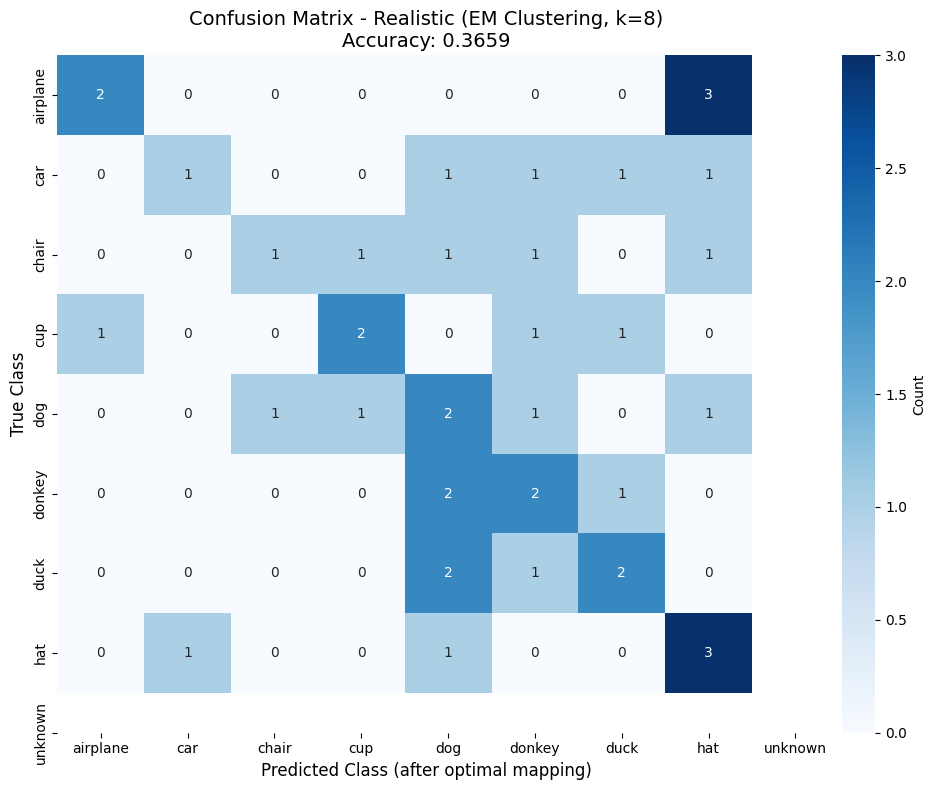


EM Clustering for: silhouettes
Feature shape: (40, 31)
Number of samples: 40
Number of clusters: 8 (ground truth)

Clustering Accuracy: 0.2750 (27.50%)

Optimal Cluster to Class Mapping:
  Cluster 3 -> Class 0 (airplane)
  Cluster 4 -> Class 1 (car)
  Cluster 5 -> Class 2 (chair)
  Cluster 2 -> Class 3 (cup)
  Cluster 1 -> Class 4 (dog)
  Cluster 6 -> Class 5 (donkey)
  Cluster 7 -> Class 6 (duck)
  Cluster 0 -> Class 7 (hat)


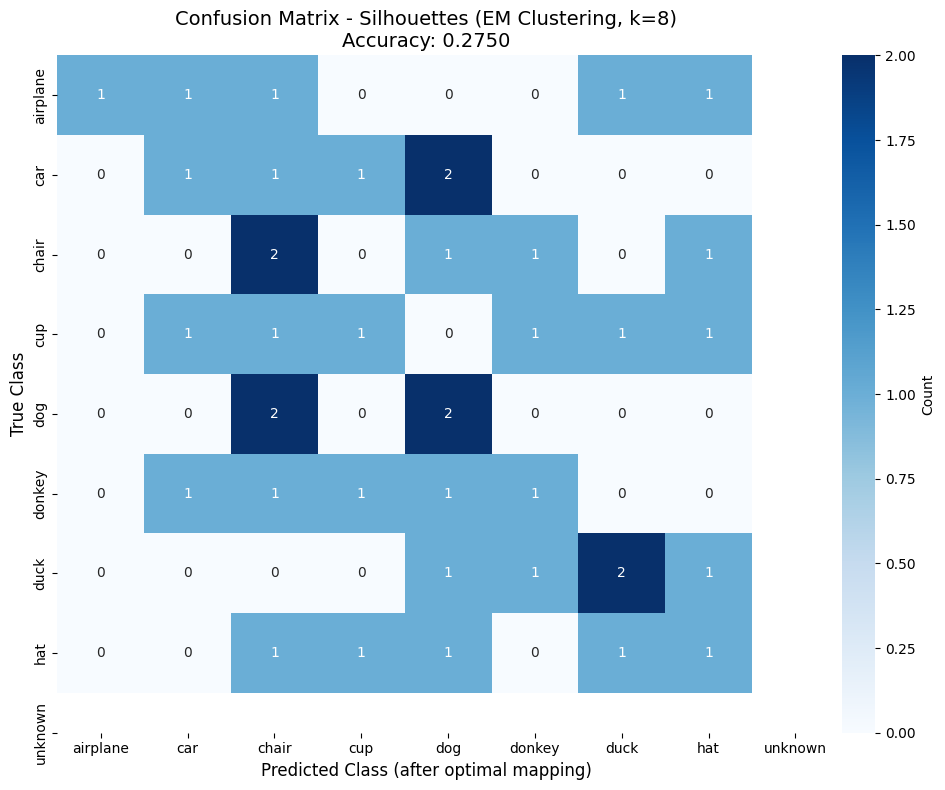


SUMMARY OF EM CLUSTERING ACCURACIES (k=8)
blurred        : 0.3571 (35.71%)
features       : 0.3571 (35.71%)
geons          : 0.2333 (23.33%)
realistic      : 0.3659 (36.59%)
silhouettes    : 0.2750 (27.50%)


In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import confusion_matrix, accuracy_score
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
import seaborn as sns

def perform_em_clustering_k8(directory):
    """
    Perform EM (Gaussian Mixture Model) clustering with k=8.

    Parameters:
    -----------
    directory : str
        Directory name in dir_info DataFrame
    """
    # Get PCA features (95% variance) and true labels
    features = dir_info.at[directory, "pca_transformed_images"]
    true_labels = dir_info.at[directory, "image_labels"]

    print(f"\n{'='*60}")
    print(f"EM Clustering for: {directory}")
    print(f"{'='*60}")
    print(f"Feature shape: {features.shape}")
    print(f"Number of samples: {len(true_labels)}")
    print(f"Number of clusters: 8 (ground truth)")

    # Perform EM clustering with k=8
    gmm = GaussianMixture(n_components=8, random_state=42, n_init=10)
    cluster_labels = gmm.fit_predict(features)

    # Calculate accuracy with optimal mapping
    accuracy, mapping, mapped_labels = cluster_accuracy(true_labels, cluster_labels)

    print(f"\nClustering Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"\nOptimal Cluster to Class Mapping:")
    class_names = list(categories.keys())
    for cluster, true_class in mapping.items():
        print(f"  Cluster {cluster} -> Class {true_class} ({class_names[true_class]})")

    # Create confusion matrix with mapped labels
    cm = confusion_matrix(true_labels, mapped_labels)

    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names,
                cbar_kws={'label': 'Count'})
    plt.xlabel('Predicted Class (after optimal mapping)', fontsize=12)
    plt.ylabel('True Class', fontsize=12)
    plt.title(f'Confusion Matrix - {directory.capitalize()} (EM Clustering, k=8)\nAccuracy: {accuracy:.4f}',
              fontsize=14)
    plt.tight_layout()
    plt.show()

    return accuracy, mapping, cluster_labels, gmm

# Perform EM clustering for all directories with k=8
em_results = {}

for dir_name in dir_info.index:
    accuracy, mapping, clusters, gmm = perform_em_clustering_k8(dir_name)
    em_results[dir_name] = {
        'accuracy': accuracy,
        'mapping': mapping,
        'clusters': clusters,
        'gmm': gmm
    }

# Summary of results
print("\n" + "="*60)
print("SUMMARY OF EM CLUSTERING ACCURACIES (k=8)")
print("="*60)
for dir_name, result in em_results.items():
    print(f"{dir_name:15s}: {result['accuracy']:.4f} ({result['accuracy']*100:.2f}%)")

In [ ]:
dir_info.columns

Index(['dir_path', 'pca_fn', 'images', 'pca_transformed_images', 'image_names',
       'image_labels', 'images_downsized', 'resnet_features'],
      dtype='object')

## 5C
Use the model to generate 5 new images for each condition (using the sample() method), and visualize them in the original image space (since you used PCA, you will need to use its inverse_transform() method).  [4 points]


Generating 5 new images for: blurred
Original image shape: (256, 256, 3)
Generated samples in PCA space: (5, 18)
Transformed to original space: (5, 196608)


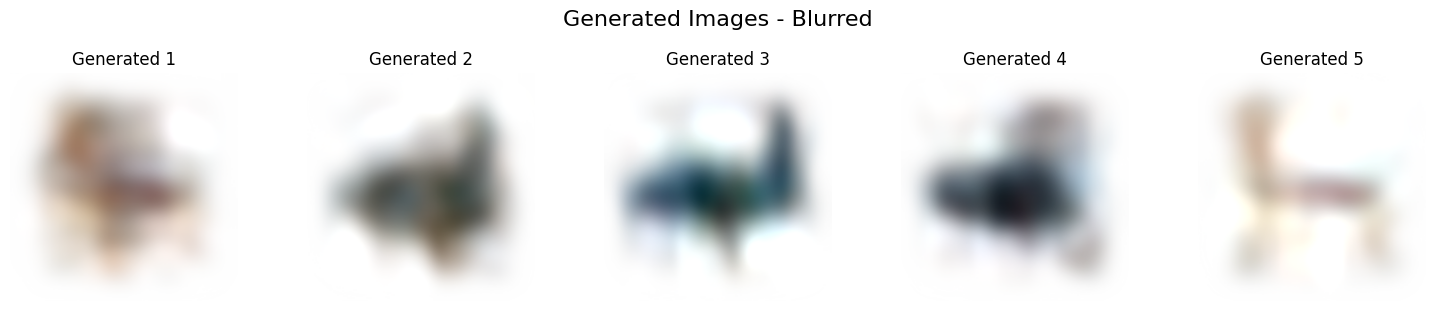


Generating 5 new images for: features
Original image shape: (256, 256, 3)
Generated samples in PCA space: (5, 32)
Transformed to original space: (5, 196608)


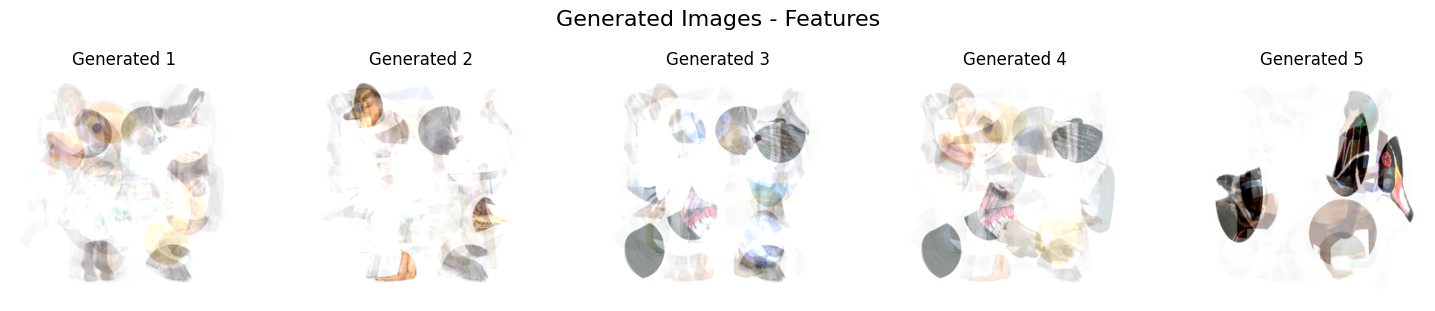


Generating 5 new images for: geons
Original image shape: (256, 256, 3)
Generated samples in PCA space: (5, 41)
Transformed to original space: (5, 196608)


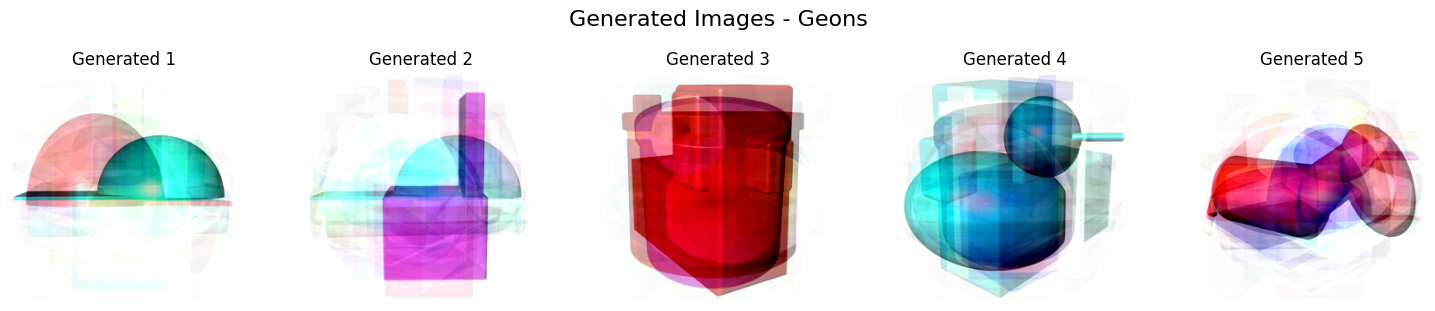


Generating 5 new images for: realistic
Original image shape: (256, 256, 3)
Generated samples in PCA space: (5, 32)
Transformed to original space: (5, 196608)


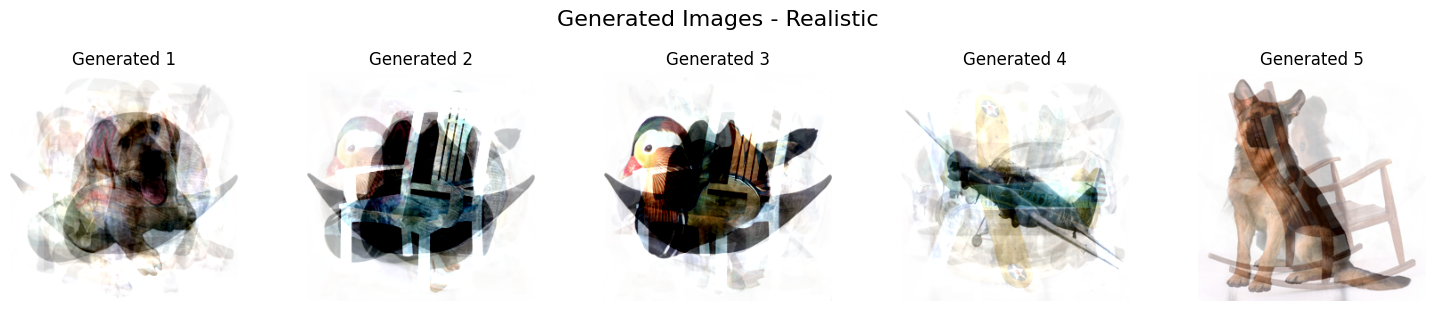


Generating 5 new images for: silhouettes
Original image shape: (256, 256, 3)
Generated samples in PCA space: (5, 31)
Transformed to original space: (5, 196608)


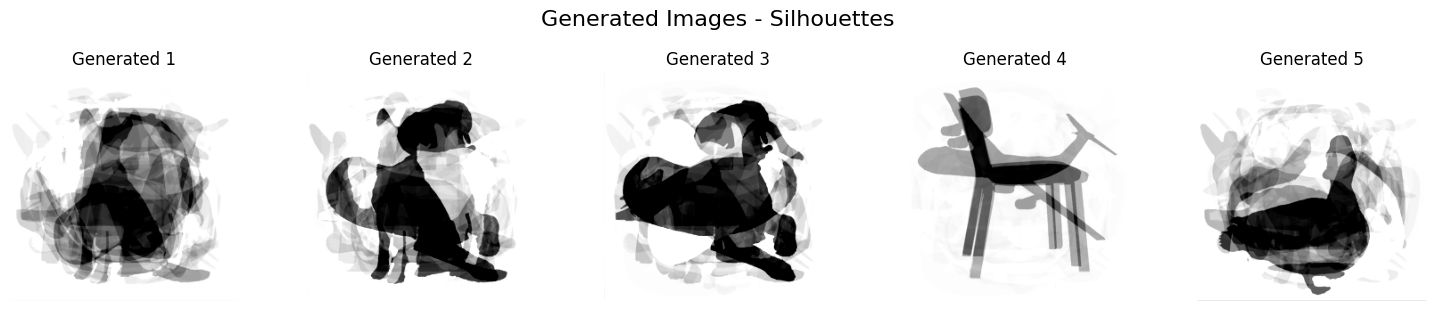

In [ ]:
def generate_new_images(directory, n_samples=5):
    """
    Generate new images using the trained GMM and visualize them.

    Parameters:
    -----------
    directory : str
        Directory name in dir_info DataFrame
    n_samples : int
        Number of images to generate
    """
    print(f"\n{'='*60}")
    print(f"Generating {n_samples} new images for: {directory}")
    print(f"{'='*60}")

    # Get the trained GMM model and PCA model
    gmm = em_results[directory]['gmm']
    pca = dir_info.at[directory, "pca_fn"]

    # Get original image shape
    original_images = dir_info.at[directory, "images"]
    original_shape = (256, 256, 3)
    print(f"Original image shape: {original_shape}")

    # Sample from the GMM in PCA space
    new_samples_pca, _ = gmm.sample(n_samples)
    print(f"Generated samples in PCA space: {new_samples_pca.shape}")

    # Transform back to original image space using inverse_transform
    new_samples_original = pca.inverse_transform(new_samples_pca)
    print(f"Transformed to original space: {new_samples_original.shape}")

    # Reshape back to image dimensions
    new_images = new_samples_original.reshape(n_samples, *original_shape)

    # Clip values to valid range [0, 255] and convert to uint8
    new_images = np.clip(new_images, 0, 255).astype(np.uint8)

    # Visualize the generated images
    fig, axes = plt.subplots(1, n_samples, figsize=(15, 3))
    if n_samples == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        if len(original_shape) == 3:  # Color image
            ax.imshow(new_images[i])
        else:  # Grayscale
            ax.imshow(new_images[i], cmap='gray')
        ax.axis('off')
        ax.set_title(f'Generated {i+1}')

    plt.suptitle(f'Generated Images - {directory.capitalize()}', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

    return new_images

# Generate new images for all directories
generated_images = {}

for dir_name in dir_info.index:
    new_imgs = generate_new_images(dir_name, n_samples=5)
    generated_images[dir_name] = new_imgs

## 5D
Repeat step B, but instead of features derived using PCA, use features obtained with a pretrained ResNet model. [3 points]


EM Clustering (ResNet Features) for: blurred
Feature shape: (42, 512)
Number of samples: 42
Number of clusters: 8 (ground truth)

Clustering Accuracy: 0.3333 (33.33%)

Optimal Cluster to Class Mapping:
  Cluster 0 -> Class 0 (airplane)
  Cluster 6 -> Class 1 (car)
  Cluster 4 -> Class 2 (chair)
  Cluster 2 -> Class 3 (cup)
  Cluster 3 -> Class 4 (dog)
  Cluster 5 -> Class 5 (donkey)
  Cluster 7 -> Class 6 (duck)
  Cluster 1 -> Class 7 (hat)


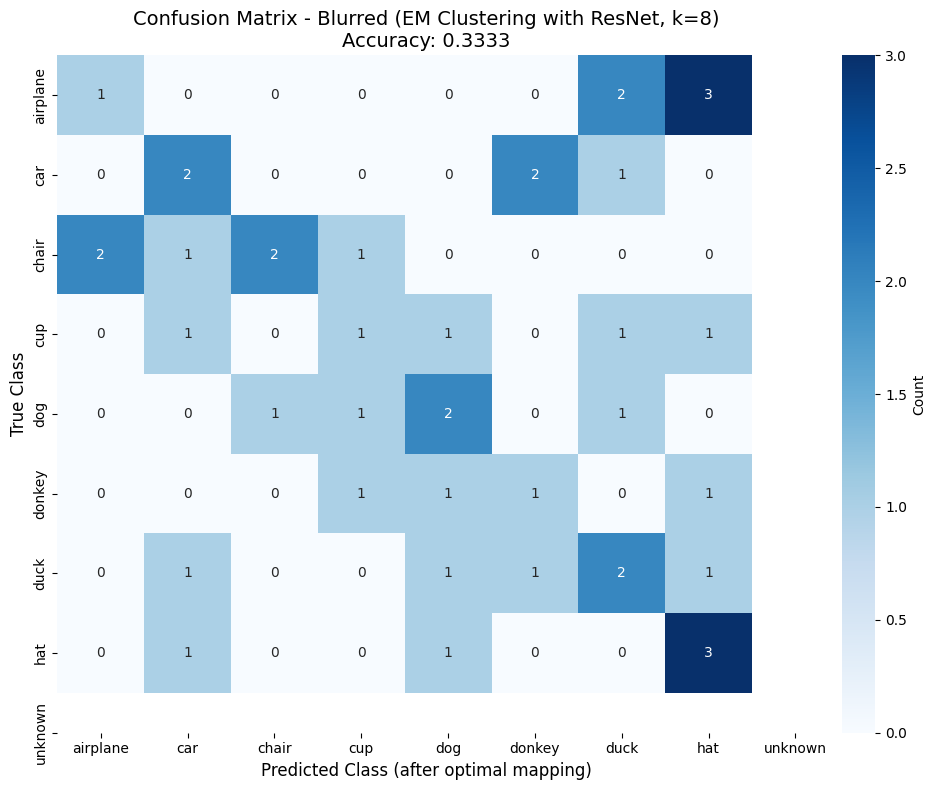


EM Clustering (ResNet Features) for: features
Feature shape: (42, 512)
Number of samples: 42
Number of clusters: 8 (ground truth)

Clustering Accuracy: 0.3333 (33.33%)

Optimal Cluster to Class Mapping:
  Cluster 1 -> Class 0 (airplane)
  Cluster 4 -> Class 1 (car)
  Cluster 6 -> Class 2 (chair)
  Cluster 7 -> Class 3 (cup)
  Cluster 3 -> Class 4 (dog)
  Cluster 0 -> Class 5 (donkey)
  Cluster 5 -> Class 6 (duck)
  Cluster 2 -> Class 7 (hat)
  Cluster 8 -> Class 8 (unknown)


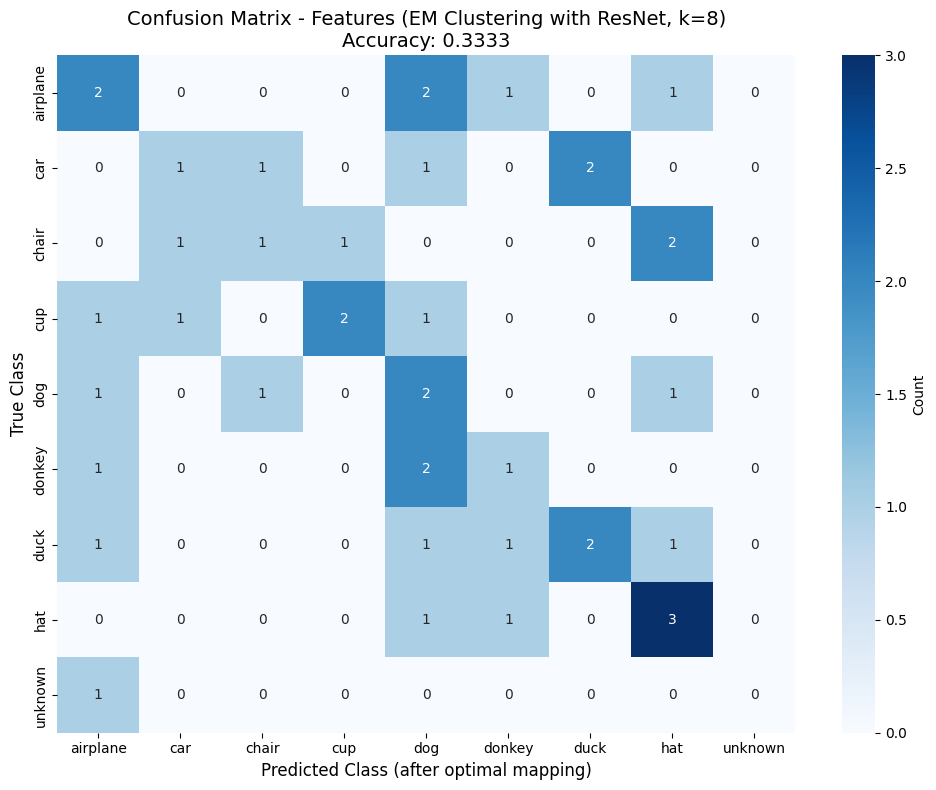


EM Clustering (ResNet Features) for: geons
Feature shape: (60, 512)
Number of samples: 60
Number of clusters: 8 (ground truth)

Clustering Accuracy: 0.3667 (36.67%)

Optimal Cluster to Class Mapping:
  Cluster 1 -> Class 0 (airplane)
  Cluster 7 -> Class 1 (car)
  Cluster 5 -> Class 2 (chair)
  Cluster 4 -> Class 3 (cup)
  Cluster 3 -> Class 4 (dog)
  Cluster 2 -> Class 5 (donkey)
  Cluster 0 -> Class 6 (duck)
  Cluster 6 -> Class 7 (hat)
  Cluster 8 -> Class 8 (unknown)


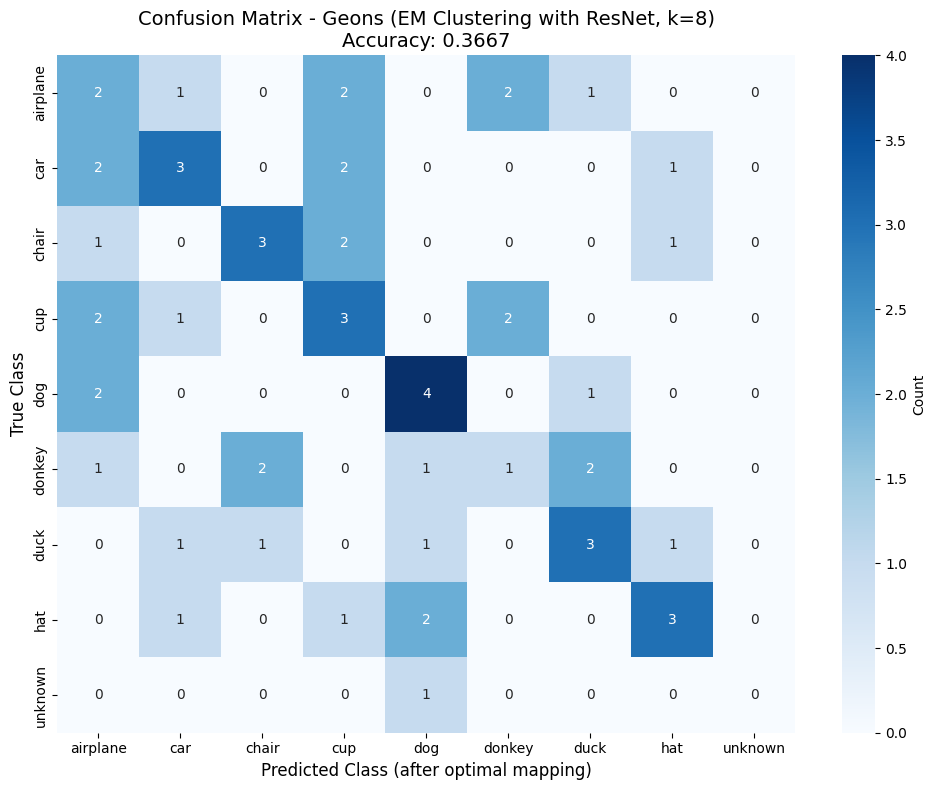


EM Clustering (ResNet Features) for: realistic
Feature shape: (41, 512)
Number of samples: 41
Number of clusters: 8 (ground truth)

Clustering Accuracy: 0.3415 (34.15%)

Optimal Cluster to Class Mapping:
  Cluster 7 -> Class 0 (airplane)
  Cluster 6 -> Class 1 (car)
  Cluster 1 -> Class 2 (chair)
  Cluster 3 -> Class 3 (cup)
  Cluster 2 -> Class 4 (dog)
  Cluster 0 -> Class 5 (donkey)
  Cluster 5 -> Class 6 (duck)
  Cluster 4 -> Class 7 (hat)


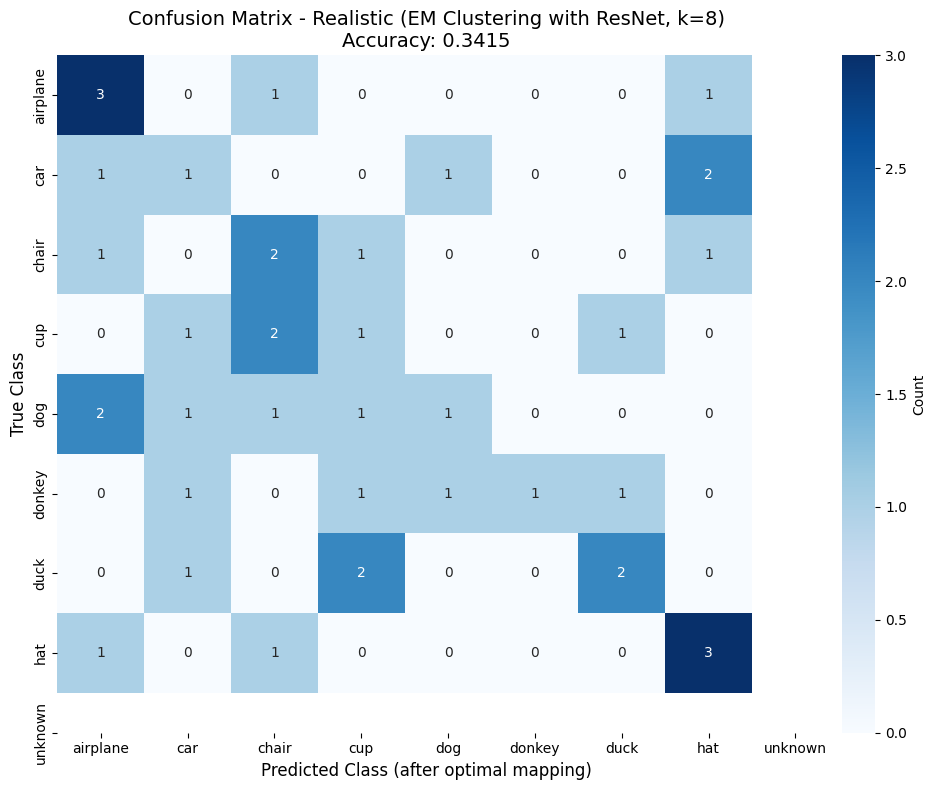


EM Clustering (ResNet Features) for: silhouettes
Feature shape: (40, 512)
Number of samples: 40
Number of clusters: 8 (ground truth)

Clustering Accuracy: 0.4000 (40.00%)

Optimal Cluster to Class Mapping:
  Cluster 6 -> Class 0 (airplane)
  Cluster 7 -> Class 1 (car)
  Cluster 2 -> Class 2 (chair)
  Cluster 3 -> Class 3 (cup)
  Cluster 4 -> Class 4 (dog)
  Cluster 1 -> Class 5 (donkey)
  Cluster 0 -> Class 6 (duck)
  Cluster 5 -> Class 7 (hat)


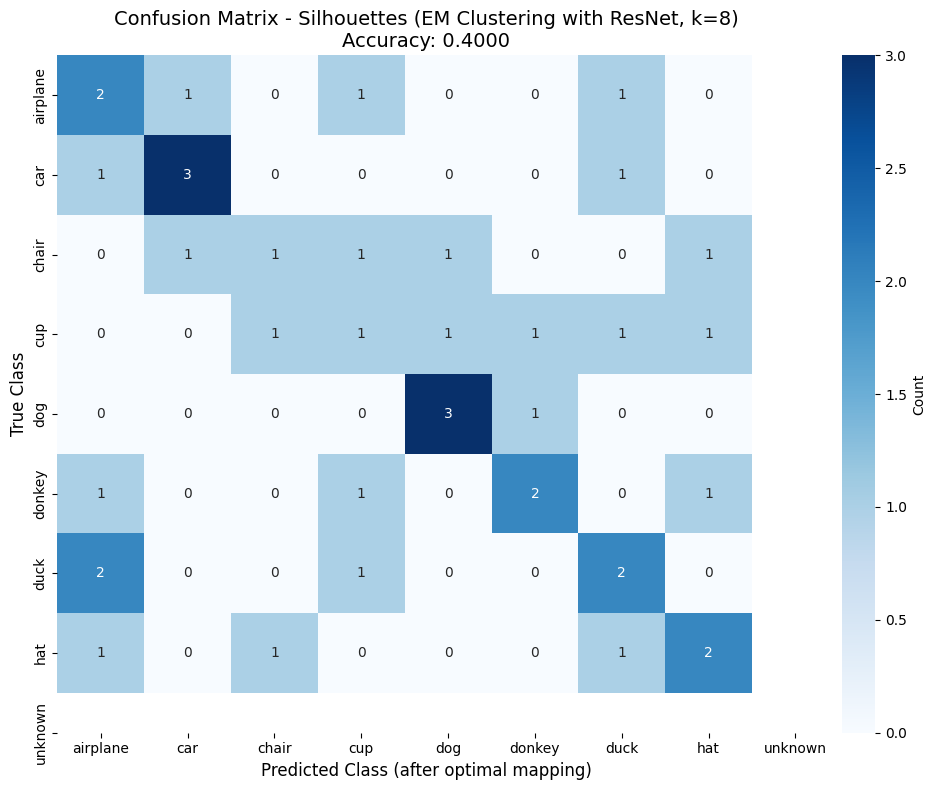


SUMMARY OF EM CLUSTERING ACCURACIES (ResNet Features, k=8)
blurred        : 0.3333 (33.33%)
features       : 0.3333 (33.33%)
geons          : 0.3667 (36.67%)
realistic      : 0.3415 (34.15%)
silhouettes    : 0.4000 (40.00%)


In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import confusion_matrix, accuracy_score
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
import seaborn as sns

def perform_em_clustering_resnet_k8(directory):
    """
    Perform EM (Gaussian Mixture Model) clustering with k=8 using ResNet features.

    Parameters:
    -----------
    directory : str
        Directory name in dir_info DataFrame
    """
    # Get ResNet features and true labels
    features = dir_info.at[directory, "resnet_features"]
    true_labels = dir_info.at[directory, "image_labels"]

    print(f"\n{'='*60}")
    print(f"EM Clustering (ResNet Features) for: {directory}")
    print(f"{'='*60}")
    print(f"Feature shape: {features.shape}")
    print(f"Number of samples: {len(true_labels)}")
    print(f"Number of clusters: 8 (ground truth)")

    # Perform EM clustering with k=8
    gmm = GaussianMixture(n_components=8, random_state=42, n_init=10)
    cluster_labels = gmm.fit_predict(features)

    # Calculate accuracy with optimal mapping
    accuracy, mapping, mapped_labels = cluster_accuracy(true_labels, cluster_labels)

    print(f"\nClustering Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"\nOptimal Cluster to Class Mapping:")
    class_names = list(categories.keys())
    for cluster, true_class in mapping.items():
        print(f"  Cluster {cluster} -> Class {true_class} ({class_names[true_class]})")

    # Create confusion matrix with mapped labels
    cm = confusion_matrix(true_labels, mapped_labels)

    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names,
                cbar_kws={'label': 'Count'})
    plt.xlabel('Predicted Class (after optimal mapping)', fontsize=12)
    plt.ylabel('True Class', fontsize=12)
    plt.title(f'Confusion Matrix - {directory.capitalize()} (EM Clustering with ResNet, k=8)\nAccuracy: {accuracy:.4f}',
              fontsize=14)
    plt.tight_layout()
    plt.show()

    return accuracy, mapping, cluster_labels, gmm

# Perform EM clustering for all directories with k=8 using ResNet features
em_results_resnet = {}

for dir_name in dir_info.index:
    accuracy, mapping, clusters, gmm = perform_em_clustering_resnet_k8(dir_name)
    em_results_resnet[dir_name] = {
        'accuracy': accuracy,
        'mapping': mapping,
        'clusters': clusters,
        'gmm': gmm
    }

# Summary of results
print("\n" + "="*60)
print("SUMMARY OF EM CLUSTERING ACCURACIES (ResNet Features, k=8)")
print("="*60)
for dir_name, result in em_results_resnet.items():
    print(f"{dir_name:15s}: {result['accuracy']:.4f} ({result['accuracy']*100:.2f}%)")

# Part 6
Build a feedforward neural network (using dense and/or CNN layers) with a few hidden layers (we suggest using Keras (within Tensorflow) or Pytorch). Train the network to classify images into two categories: cars and ducks, using this dataset: https://osf.io/j2sfb/files/4enzw (use only images of cars and ducks to train the networks, 80% for training and 20% for validation; you can use data augmentation; local download link here Download here). Test the network on all images of ducks and cars (all conditions) from the dataset you used in earlier questions: https://osf.io/ba4g2. For your network, choose the number of neurons you find appropriate and efficient (so you have enough time to run it). Train the network for multiple epochs until it converges (if the process is too slow, tweak the learning rate and consider simplifying your network). We will not deduct points based on the simplicity of your network, but we expect you to have performance that is above chance performance that could be obtained with an untrained network - in other words, we expect to see train and validation loss decrease and accuracy increase throughout the training. We recommend using Colab (the free version should be totally fine), but make sure to run it with a GPU to speed up the training - to add a GPU on Colab, go to Edit->Notebook settings.

Using device: cuda
Loading all data...
Total samples: 175
Training samples: 112 (64.0%)
Validation samples: 28 (16.0%)
Test samples: 35 (20.0%)

Model architecture:
CarDuckCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout_conv): Dropout2d(p=0.25, inplace=False)
  (fc1): Linear(in_features=100352, out_features=256, bias=True)
  (dropout_fc): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=2, bias=True)
  (relu): ReLU()


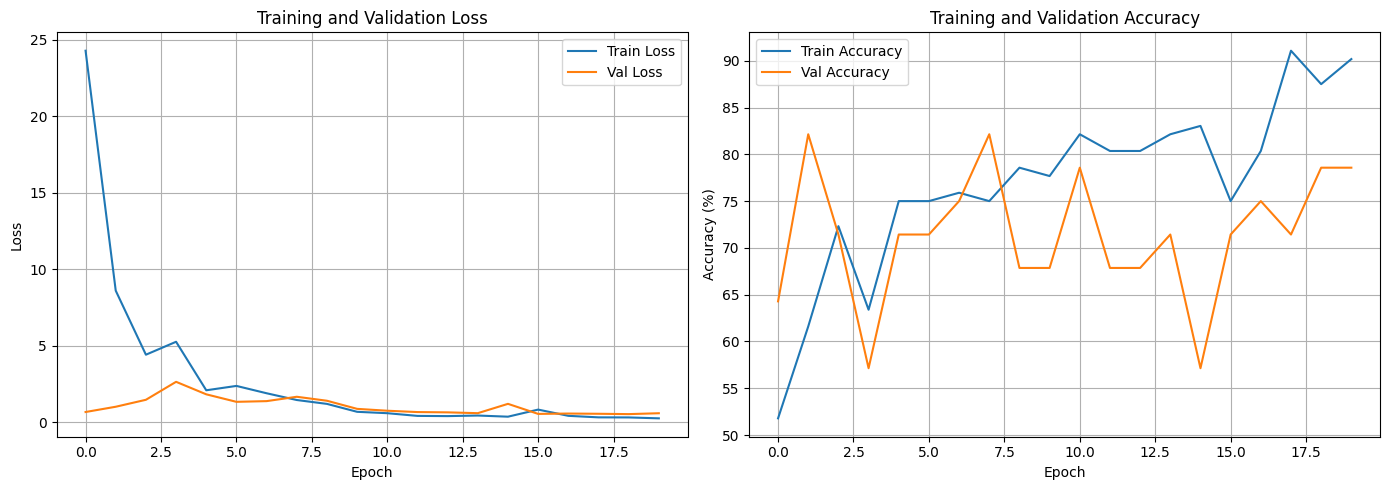

Model saved as car_duck_cnn.pth

Evaluating on held-out test data...
Test Accuracy: 77.14%


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import time

# Set random seeds for reproducibility
def set_seed(seed=SEED):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # for multi-GPU
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Custom Dataset class
class CarDuckDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

# Define CNN architecture
class CarDuckCNN(nn.Module):
    def __init__(self):
        super(CarDuckCNN, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout_conv = nn.Dropout2d(0.25)

        # Fully connected layers
        # After 3 pooling layers: 224 -> 112 -> 56 -> 28
        self.fc1 = nn.Linear(128 * 28 * 28, 256)
        self.dropout_fc = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 2)

        self.relu = nn.ReLU()

    def forward(self, x):
        # Conv block 1
        x = self.pool(self.relu(self.bn1(self.conv1(x))))

        # Conv block 2
        x = self.pool(self.relu(self.bn2(self.conv2(x))))

        # Conv block 3
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = self.dropout_conv(x)

        # Flatten
        x = x.view(x.size(0), -1)

        # Fully connected layers
        x = self.relu(self.fc1(x))
        x = self.dropout_fc(x)
        x = self.fc2(x)

        return x

# Data augmentation and normalization
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load all data from single folder
def load_all_data(data_path):
    """
    Load images from a single dataset folder.
    Expected structure: data_path/cars/ and data_path/ducks/
    """
    image_paths = []
    labels = []

    # Load car images (label 0)
    car_path = os.path.join(data_path, 'cars')
    if os.path.exists(car_path):
        for img_name in os.listdir(car_path):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_paths.append(os.path.join(car_path, img_name))
                labels.append(0)

    # Load duck images (label 1)
    duck_path = os.path.join(data_path, 'ducks')
    if os.path.exists(duck_path):
        for img_name in os.listdir(duck_path):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_paths.append(os.path.join(duck_path, img_name))
                labels.append(1)

    return image_paths, labels

# Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=20):
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        train_loss /= len(train_loader)
        train_acc = 100 * train_correct / train_total

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = 100 * val_correct / val_total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f'Epoch [{epoch+1}/{num_epochs}]')
        print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
        print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
        print('-' * 60)

    return train_losses, val_losses, train_accs, val_accs

# Evaluation function
def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Test Accuracy: {accuracy:.2f}%')
    return accuracy

# Plot training history
def plot_training_history(train_losses, val_losses, train_accs, val_accs):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loss plot
    ax1.plot(train_losses, label='Train Loss')
    ax1.plot(val_losses, label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.legend()
    ax1.grid(True)

    # Accuracy plot
    ax2.plot(train_accs, label='Train Accuracy')
    ax2.plot(val_accs, label='Val Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Training and Validation Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

# Main execution
if __name__ == '__main__':
    # Set path - MODIFY THIS TO YOUR PATH
    data_path = Path() / 'q6_files'  # Single folder with cars/ and ducks/ subfolders

    # Load all data
    print('Loading all data...')
    image_paths, labels = load_all_data(data_path)
    print(f'Total samples: {len(image_paths)}')

    # First split: 80% train+val, 20% test
    train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
        image_paths, labels, test_size=0.2, random_state=42, stratify=labels
    )

    # Second split: Split the 80% into 80% train (64% of total) and 20% val (16% of total)
    train_paths, val_paths, train_labels, val_labels = train_test_split(
        train_val_paths, train_val_labels, test_size=0.2, random_state=42, stratify=train_val_labels
    )

    print(f'Training samples: {len(train_paths)} ({len(train_paths)/len(image_paths)*100:.1f}%)')
    print(f'Validation samples: {len(val_paths)} ({len(val_paths)/len(image_paths)*100:.1f}%)')
    print(f'Test samples: {len(test_paths)} ({len(test_paths)/len(image_paths)*100:.1f}%)')

    # Create datasets and dataloaders
    train_dataset = CarDuckDataset(train_paths, train_labels, train_transform)
    val_dataset = CarDuckDataset(val_paths, val_labels, val_transform)
    test_dataset = CarDuckDataset(test_paths, test_labels, val_transform)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

    # Initialize model, loss, and optimizer
    model = CarDuckCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    print(f'\nModel architecture:')
    print(model)
    print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters())}')

    training_start = time.perf_counter()

    # Train the model
    print('\nStarting training...')
    train_losses, val_losses, train_accs, val_accs = train_model(
        model, train_loader, val_loader, criterion, optimizer, num_epochs=20
    )

    training_end = time.perf_counter()
    print(f'\n6A Training time: {training_end - training_start:.1f} seconds')

    # Plot training history
    plot_training_history(train_losses, val_losses, train_accs, val_accs)

    # Save the model
    torch.save(model.state_dict(), 'car_duck_cnn.pth')
    print('Model saved as car_duck_cnn.pth')

    # Evaluate on test data
    print('\nEvaluating on held-out test data...')
    test_accuracy = evaluate_model(model, test_loader)

## 6A
Report the training time (use code to do this). [1 point]

See above

## 6B
Plot training and validation loss and accuracy as a function of training epochs. [8 points]

See above

## 6C
How many parameters does the network have? How many of those parameters are bias parameters? [2 point]

It has 25784578 parameters, 706 of which are bias.

# References

https://www.geeksforgeeks.org/machine-learning/implementing-pca-in-python-with-scikit-learn/

Hands-on Machine Learning textbook

Claude throughout

# Errata

I am leaving this here as a reminder to myself to try implementing regex matching in Python myself.

In [ ]:
# from enum import Enum
# import re

# class Category(Enum):
#   Airplane = "Airplane"
#   Car = "Car"
#   Chair = "Chair"
#   Cup = "Cup"
#   Dog = "Dog"
#   Donkey = "Donkey"
#   Duck = "Duck"
#   Hat = "Hat"

# def categorize_images(directory):
#   categories = []
#   for filename in os.listdir(path):
#     match filename:
#       case r"^Airplane": categories.append(Category.Airplane)
#       case r"^Car": categories.append(Category.Car)
#       case r"^Chair": categories.append(Category.Chair)
#       case r"^Cup": categories.append(Category.Cup)
#       case r"^Dog": categories.append(Category.Dog)
#       case r"^Donkey": categories.append(Category.Donkey)
#       case r"^Duck": categories.append(Category.Duck)
#       case r"^Hat": categories.append(Category.Hat)
#   return categories